# Exhaustive validation & comparative analysis
### Two-class non-preemptive priority M/M/1 with jockeying and abandonment

This notebook is **comparative, convergence-oriented, and figure-producing**. It does
**not** re-prove the theorems (see `nb_validation.ipynb` for the Thm/Cor validation of
Models A, B₂, C₂ against the CTMC). It complements `nb_results.ipynb` with
publication-quality figures saved to `figures/results/`.

**Notation (binding).** $N_1,N_2,N=N_1+N_2$ count customers *waiting in the queues*; the
customer in service is **implicit** and never counted. A tuple state $(n_1,n_2)$ always
implies the server is **busy**. $\pi_0=\mathbb P(\text{idle})$ and
$\pi(0,0)=\mathbb P(\text{busy, both queues empty})$ are **distinct**: $\pi(0,0)\neq\pi_0$.

**Models.** A (baseline, $\gamma=\theta=0$); B₂ (one-way jockeying $1\!\to\!2$, rate
$\gamma_1$); C₂ (class-1 abandonment, rate $\theta_1$). Throughput $=\mu\,\mathbb P(\text{busy})$.

**Stability.** Without abandonment, stable iff $\rho=(\lambda_1+\lambda_2)/\mu<1$. With
$\theta_1>0$ (Model C₂) the chain is **positive recurrent for all loads**.


## Section 0 — Shared setup

Imports the CTMC solvers, defines PGF/Little's-Law helpers, the closed-form evaluators
(copied verbatim from `build_nb_validation.py` for self-containment), the consistent
colour scheme (A = black solid, B₂ = steelblue dashed, C₂ = crimson dash-dot), and the
`savefig` helper that writes both `.pdf` and `.png` at 150 dpi to `figures/results/`.

In [1]:

%matplotlib inline
import os, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy.special import hyp1f1
from scipy.integrate import quad

from model_master import (
    Params, solve_exact, simulate, diagnostics, mean_queue_lengths, marginals,
    model_B21, model_C21,
)
from model_master_tilde import solve_exact_tilde, marginals_tilde

# ── Matplotlib style (matches build_nb_validation.py) ─────────────────────────
plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

# ── Consistent cross-notebook colour scheme ───────────────────────────────────
C_A,   LS_A   = "black",     "-"          # Model A    = black solid (reference baseline)
C_B,   LS_B   = "darkorange","--"         # Model B    = orange dashed (two-way jockeying, CTMC only)
C_B2,  LS_B2  = "steelblue", "--"         # Model B2   = steelblue dashed (full-rate jockeying)
C_C2,  LS_C2  = "crimson",   "-."         # Model C2   = crimson dash-dot (full-rate abandonment)
C_B21, LS_B21 = "teal",      ":"          # Model B2^1 = teal dotted  (head-of-line jockeying)
C_C21, LS_C21 = "darkviolet",":"          # Model C2^1 = violet dotted (head-of-line abandonment)
# (string fmt only: plot() loops pass the linestyle as a positional format string, which
#  does not accept tuple dash patterns; B2^1/C2^1 are told apart by colour, not dash.)

# ── Output directory + savefig helper ─────────────────────────────────────────
SAVE_DIR = "../figures/results/"
os.makedirs(SAVE_DIR, exist_ok=True)

def savefig(name):
    '''Save the current figure as BOTH pdf and png (dpi=150); print the paths.'''
    base = os.path.join(SAVE_DIR, name)
    for ext in ("pdf", "png"):
        path = f"{base}.{ext}"
        plt.savefig(path, dpi=150)
        print("saved:", os.path.abspath(path))

# ── Canonical parameters (shared with the other notebooks) ────────────────────
MU            = 1.0          # always normalised
LAM1_SYM, LAM2_SYM = 0.35, 0.35     # symmetric:  rho = 0.70
LAM1_ASYM, LAM2_ASYM = 0.50, 0.20   # asymmetric: heavy prio class, rho = 0.70
LAM1_STD, LAM2_STD = 0.30, 0.40     # standard (matches existing notebooks), rho = 0.70
GAMMA1_CANON  = 0.50
GAMMA2_CANON  = 0.30   # full Model-B second direction (2->1); matches build_notebook.py
THETA1_CANON  = 0.50
N_MAX_DEFAULT = 50
RHO_SWEEP     = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.75,
                 0.80, 0.85, 0.90, 0.95]

print("setup OK — output dir:", os.path.abspath(SAVE_DIR))


setup OK — output dir: /Users/victor/GitVictor/M-Thesis---Notes/figures/results


### Core helpers — PGF evaluation, Little's Law, adaptive solve

In [2]:

def pgf_series(pi_joint, x, y):
    """Evaluate P(x,y) = sum_{n1,n2} pi(n1,n2) x^{n1} y^{n2} by direct summation
    (scalar or array x,y). Returns complex; take .real for real inputs."""
    M = pi_joint.shape[0]
    X, Y = np.broadcast_arrays(np.asarray(x, complex), np.asarray(y, complex))
    R = np.zeros_like(X, dtype=complex)
    for n1 in range(M):
        for n2 in range(M):
            if pi_joint[n1, n2] > 1e-15:
                R = R + pi_joint[n1, n2] * X**n1 * Y**n2
    return R

def L1_distance(pi_a, pi_b):
    """L1 norm ||pi_a - pi_b||_1 of two pi_joint arrays, zero-padded to the larger size."""
    Ma, Mb = pi_a.shape[0], pi_b.shape[0]
    M = max(Ma, Mb)
    A = np.zeros((M, M)); A[:Ma, :Ma] = pi_a
    B = np.zeros((M, M)); B[:Mb, :Mb] = pi_b
    return float(np.abs(A - B).sum())

def EN1_EN2(pi_joint):
    """(E[N1], E[N2]) — in-queue means (in-service customer excluded)."""
    return mean_queue_lengths(pi_joint)

def EW1_EW2(p, pi_joint):
    """(E[W1], E[W2]) via Little's Law: E[Wi] = E[Ni] / lam_i.
    Little's Law applied to each class queue: mean number waiting = arrival rate into
    the queue * mean time spent waiting. Every class-i arrival enters its queue at rate
    lam_i (abandoners included), so lam_i is the correct rate even under abandonment."""
    En1, En2 = mean_queue_lengths(pi_joint)
    return En1 / p.lam1, En2 / p.lam2

def solve_adaptive(p, N_max=N_MAX_DEFAULT, tail_tol=1e-8, cap=100):
    """solve_exact with adaptive truncation. Doubles N_max until the boundary tail mass
    < tail_tol (Section 3 of the spec), capped at `cap` for memory feasibility of the
    dense 2D solve. Returns (result_dict, diagnostics_dict, N_used, tail_mass).
    Near rho->1 the geometric tail is heavy and `cap` may bind; the tail mass is returned
    so callers can report it instead of silently trusting a truncated result."""
    nm = N_max
    while True:
        r = solve_exact(p, N_max=nm)
        pij = r["pi_joint"]
        tail = float(pij[nm-4:, :].sum() + pij[:, nm-4:].sum())
        if tail < tail_tol or nm >= cap:
            break
        nm = min(nm * 2, cap)
    d = diagnostics(p, r["pi_idle"], pij)
    return r, d, nm, tail


### Closed-form PGF evaluators (copied from `build_nb_validation.py`)

These mirror the thesis theorems. Model A is exact-rational; B₂ and C₂ use the confluent
hypergeometric ${}_1F_1$ and an Euler-type integral, valid for real $0<x<y<1$. They are
kept here for self-containment and for the $E[B_C]$ and $\pi_0,\pi(0,0)$ formulas of C₂.

In [3]:

def make_P_A(lam1, lam2, mu):
    """Model A closed-form joint PGF P(x,y) (Theorem A)."""
    rho1, rho2, rho = lam1/mu, lam2/mu, (lam1+lam2)/mu
    def x_star(y):
        A = mu + lam1 + lam2*(1 - y)
        return (A - np.sqrt(A**2 - 4*lam1*mu + 0j)) / (2*lam1)
    def P_A(x, y):
        xs    = x_star(y)
        denom = (1+rho1+rho2)*x*y - y - rho1*x**2*y - rho2*x*y**2
        num   = y*(1-y) * (x - xs)/(xs - y) * rho*(1-rho)
        return num / denom
    return P_A, x_star, rho1, rho2, rho

def make_P_B2(lam1, lam2, mu, gamma1):
    """Model B2 closed-form: boundary PGF Py(y) and integral-form P(x,y) (Theorem B2)."""
    lam  = lam1 + lam2
    rho  = lam / mu
    pi00 = rho * (1 - rho)            # jockeying conserves N: pi(0,0)=rho(1-rho) for all gamma1
    c    = lam1 / gamma1
    def alpha(y): return mu / (gamma1 * y)
    def beta(y):  return (1 - y) * (lam * y - mu) / (gamma1 * y)
    def bstar(y): return alpha(y) + beta(y) + 1
    def Py_B2(y):
        a, bs = alpha(y), bstar(y)
        z = -lam1 * y / gamma1
        return mu * pi00 / (mu - lam*y) * hyp1f1(a+1, bs, z) / hyp1f1(a, bs, z)
    def I1(xv, yv):
        a, b = alpha(yv), beta(yv)
        def f(t): return np.exp(-c*t) * t**(a-1) * (yv-t)**b if t > 0 else 0.0
        val, _ = quad(f, 0, xv, limit=200); return val
    def I2(xv, yv):
        a, b = alpha(yv), beta(yv)
        def f(t): return np.exp(-c*t) * t**a * (yv-t)**(b-1) if t > 0 else 0.0
        val, _ = quad(f, 0, xv, limit=200); return val
    def P_B2(xv, yv):
        # Evaluate for scalar real 0 < xv < yv < 1.
        a, b = alpha(yv), beta(yv)
        py = Py_B2(yv)
        i1, i2 = I1(xv, yv), I2(xv, yv)
        prefactor = mu * np.exp(c*xv) * xv**(-a) * (yv-xv)**(-b) / (gamma1*yv)
        return prefactor * (py*i1 + (1-yv)*pi00*i2)
    return P_B2, Py_B2, pi00, rho

def make_P_C2(lam1, lam2, mu, theta1):
    """Model C2 closed-form: busy-period LST, E[B_C], pi0, pi(0,0), P(x,y) (Theorem/Cor C2)."""
    alpha = mu / theta1
    c     = lam1 / theta1
    def beta(y): return lam2*(1-y) / theta1
    def BcLST(y):
        b = beta(np.asarray(y, float))
        return (alpha/(alpha+b)) * hyp1f1(alpha+1, alpha+1+b, -c) / hyp1f1(alpha, alpha+b, -c)
    def E_BC(): return hyp1f1(1, alpha+1, lam1/theta1) / mu   # -> 1/(mu-lam1) as theta1->0
    def pi0():
        eb = E_BC(); return (1 - lam2*eb) / (1 + lam1*eb)
    def pi00(): return (lam1+lam2)/mu * pi0()
    def I_k(k, xv, yv):
        b = beta(yv); t_pow = alpha - 1 + (k-1); s_pow = b - (k-1)
        def f(t):
            if t <= 0 or t >= 1: return 0.0
            return np.exp(-c*t) * t**t_pow * (1-t)**s_pow
        val, _ = quad(f, 0, min(xv, 1-1e-10), limit=200); return val
    def P_C2(xv, yv):
        b = beta(yv); zeta = BcLST(yv)
        i1, i2 = I_k(1, xv, yv), I_k(2, xv, yv)
        num = np.exp(c*xv) * mu * pi00() * (1-yv) * (zeta*i1 - (1-zeta)*i2)
        den = theta1 * xv**alpha * (1-xv)**b * (zeta - yv)
        return num / den
    return P_C2, BcLST, E_BC, pi0, pi00

def E_BC_value(lam1, mu, theta1):
    """Mean class-1 busy period of the M/M/1+M subsystem; theta1=0 -> 1/(mu-lam1)."""
    if theta1 == 0:
        return 1.0 / (mu - lam1)
    return hyp1f1(1, mu/theta1 + 1, lam1/theta1) / mu

# ── Head-of-line experiment models B2^1 and C2^1 (rational closed forms) ───────
# These are the closed-form descriptors of Sections (Model B2^1) and (Model C2^1):
# the head-of-line mechanism fires at the constant rate gamma1 / theta1 * 1{n1>=1},
# which keeps P(x,y) rational. They mirror Model A with mu -> mu+gamma1 y (B2^1) or
# mu -> mu+theta1 (C2^1) in the kernel.
def b21_closed(lam1, lam2, mu, gamma1):
    """Model B2^1 descriptors (eq:B21:pi0_pi00, EN1, EN, EN2). Jockeying conserves N,
    so pi0=1-rho and pi(0,0)=rho(1-rho) exactly, as in Model A."""
    lam = lam1 + lam2; rho = lam/mu
    rhoB = lam1/(mu + gamma1)               # jockeying-reduced priority load
    EN1  = rho*rhoB/(1 - rhoB)
    EN   = rho**2/(1 - rho)                 # M/M/1 total (conservation)
    EN2  = EN - EN1
    Lam2 = lam2 + gamma1*rho*rhoB           # mixed Queue-2 entrance rate (P(N1>=1)=rho rhoB)
    return dict(pi0=1-rho, pi00=rho*(1-rho), EN1=EN1, EN2=EN2, EN=EN,
                EW1=EN1/lam1, EW2=EN2/Lam2, rhoB=rhoB)

def c21_closed(lam1, lam2, mu, theta1):
    """Model C2^1 descriptors (eq:C21:pi0_pi00, EN1, EN2). Abandonment is a true
    departure, so conservation is broken: pi0 > 1-rho and EN < rho^2/(1-rho)."""
    lam = lam1 + lam2
    rhoC = lam1/(mu + theta1)               # abandonment-reduced priority load
    D0   = mu*(mu + theta1) + lam1*theta1
    npi0 = (mu + theta1)*(mu - lam) + lam1*theta1   # stability numerator (>0 iff stable)
    pi0  = npi0/D0
    pi00 = lam*pi0/mu
    one_minus_pi0 = lam*(mu + theta1)/D0
    EN1  = one_minus_pi0*rhoC/(1 - rhoC)
    EN2  = (lam2*lam*(mu + theta1)*((mu + theta1)**2 - lam1*theta1)) \
           / ((mu + theta1 - lam1)*D0*npi0)
    EN   = EN1 + EN2
    return dict(pi0=pi0, pi00=pi00, EN1=EN1, EN2=EN2, EN=EN,
                EW1=EN1/lam1, EW2=EN2/lam2, rhoC=rhoC)

print("closed-form evaluators defined (incl. head-of-line B2^1, C2^1)")


closed-form evaluators defined (incl. head-of-line B2^1, C2^1)


## Section 1 — Sanity-check suite (run first, fail fast)

We verify the baseline identities on the three canonical parameter sets (standard,
symmetric, asymmetric), all at $\rho=0.70$. A FAIL raises `AssertionError` so the notebook
stops immediately rather than propagating wrong numbers.

**Which identity applies to which model (CLAUDE.md).** $\pi_0=1-\rho$, $\pi(0,0)=\rho(1-\rho)$,
and the diagonal $P(z,z)=\pi(0,0)/(1-\rho z)$ are **Model-A baseline identities**. Jockeying
conserves the total count $N$, so the total-count chain is still M/M/1 and they hold
**exactly for B₂ and the head-of-line variant $B_2^{\mathrm{H}}$**. Abandonment is a true departure: it
makes $\pi_0>1-\rho$ and destroys the M/M/1 total-count structure, so for **C₂ and $C_2^{\mathrm{H}}$**
these three are recorded as *informational deviations*, not asserted. $P(1,1)=1-\pi_0$,
normalisation, and Little's-Law consistency hold for **all** models and are asserted
everywhere. For the two head-of-line experiment models the **rational closed forms** of their
sections (e.g.\ $\pi_0,\pi(0,0),\mathbb{E}[N_1],\mathbb{E}[N_2]$, and the flow balance
throughput $+$ abandonment $=$ offered load) are additionally asserted against the CTMC.

### [Sanity suite — baseline identities]
**Validation method:** CTMC exact solver + `pgf_series`.
**Parameters:** $\mu=1$; three sets each with $\rho=0.70$ (standard $\lambda=(0.3,0.4)$,
symmetric $(0.35,0.35)$, asymmetric $(0.5,0.2)$); B uses $\gamma_1=0.5$, $\gamma_2=0.3$;
B₂ uses $\gamma_1=0.5$, C₂ uses $\theta_1=0.5$.

In [4]:

CANON_SETS = [
    ("standard",   LAM1_STD,  LAM2_STD),
    ("symmetric",  LAM1_SYM,  LAM2_SYM),
    ("asymmetric", LAM1_ASYM, LAM2_ASYM),
]
Z_DIAG = [0.3, 0.5, 0.7, 0.9]

def build_models(lam1, lam2):
    # (name, Params, mm1_identities_hold, closed_form_or_None)
    return [
        ("A",    Params(lam1, lam2, MU),                       True,  None),
        ("B",    Params(lam1, lam2, MU, gamma1=GAMMA1_CANON,
                        gamma2=GAMMA2_CANON),                  True,  None),  # open model: CTMC only
        ("B2",   Params(lam1, lam2, MU, gamma1=GAMMA1_CANON),  True,  None),
        ("B2^1", model_B21(lam1, lam2, MU, GAMMA1_CANON),      True,
                 b21_closed(lam1, lam2, MU, GAMMA1_CANON)),    # head-of-line jockeying: conserves N
        ("C2",   Params(lam1, lam2, MU, theta1=THETA1_CANON),  False, None),  # mm1-identities don't hold
        ("C2^1", model_C21(lam1, lam2, MU, THETA1_CANON),      False,
                 c21_closed(lam1, lam2, MU, THETA1_CANON)),    # head-of-line abandonment: breaks conservation
    ]

rows = []
failures = []
for setname, lam1, lam2 in CANON_SETS:
    rho = (lam1 + lam2) / MU
    for mname, p, mm1, cf in build_models(lam1, lam2):
        r, d, nm, tail = solve_adaptive(p, N_max=N_MAX_DEFAULT)
        pij, pi0 = r["pi_joint"], r["pi_idle"]
        pi00 = pij[0, 0]
        P11 = pgf_series(pij, 1.0, 1.0).real

        # --- head-of-line experiment models: assert rational closed forms vs CTMC ---
        if cf is not None:
            En1c, En2c = EN1_EN2(pij)
            assert abs(pi0 - cf["pi0"]) < 1e-4,   f"{mname} pi0 closed-form {setname}: {pi0} vs {cf['pi0']}"
            assert abs(pi00 - cf["pi00"]) < 1e-4, f"{mname} pi00 closed-form {setname}"
            assert abs(En1c - cf["EN1"]) < 1e-3,  f"{mname} E[N1] closed-form {setname}: {En1c} vs {cf['EN1']}"
            assert abs(En2c - cf["EN2"]) < 1e-3,  f"{mname} E[N2] closed-form {setname}: {En2c} vs {cf['EN2']}"
            # flow balance (steady state): throughput + abandonment rate = offered load
            assert abs(d["carried_plus_lost"] - d["offered_load"]) < 1e-4, f"{mname} flow balance {setname}"
            rows.append((setname, mname, "closed-form E[N1] vs CTMC", En1c, cf["EN1"], "PASS"))
            rows.append((setname, mname, "closed-form E[N2] vs CTMC", En2c, cf["EN2"], "PASS"))

        # --- universal checks (all models) ---
        norm = pi0 + pij.sum()
        assert abs(norm - 1.0) < 1e-6, f"normalisation {setname}/{mname}: {norm}"
        assert abs(P11 - (1 - pi0)) < 1e-4, f"P(1,1) {setname}/{mname}: {P11} vs {1-pi0}"
        En1, En2 = EN1_EN2(pij)
        assert abs(d["E_n"] - (En1 + En2)) < 1e-4, "Little consistency"
        rows.append((setname, mname, "P(1,1)=1-π₀", P11, 1-pi0, "PASS"))
        rows.append((setname, mname, "normalisation", norm, 1.0, "PASS"))

        # --- Little's Law consistency: E[N] = lam1 E[W1] + lam2 E[W2] ---
        Ew1, Ew2 = EW1_EW2(p, pij)
        little = lam1 * Ew1 + lam2 * Ew2
        assert abs(little - d["E_n"]) < 1e-4, "Little's Law"
        rows.append((setname, mname, "E[N]=λ₁E[W₁]+λ₂E[W₂]", little, d["E_n"], "PASS"))

        # --- Model-A identities (conserving models A, B, B2, B2^1 only) ---
        if mm1:
            assert abs(pi0 - (1-rho)) < 1e-5, f"pi0 {setname}/{mname}"
            assert abs(pi00 - rho*(1-rho)) < 1e-5, f"pi00 {setname}/{mname}"
            rows.append((setname, mname, "π₀=1−ρ", pi0, 1-rho, "PASS"))
            rows.append((setname, mname, "π(0,0)=ρ(1−ρ)", pi00, rho*(1-rho), "PASS"))
            for z in Z_DIAG:
                lhs = pgf_series(pij, z, z).real
                rhs = pi00 / (1 - rho*z)
                assert abs(lhs - rhs) < 1e-4, f"diag z={z} {setname}/{mname}"
            rows.append((setname, mname, f"P(z,z)=π(0,0)/(1−ρz) z∈{Z_DIAG}", 0.0, 0.0, "PASS"))
        else:
            # C2: record the (expected) deviation, do NOT assert
            rows.append((setname, mname, "π₀ vs 1−ρ", pi0, 1-rho, "INFO (π₀>1−ρ)"))
            rows.append((setname, mname, "π(0,0) vs ρ(1−ρ)", pi00, rho*(1-rho), "INFO (deviates)"))
            zmax_dev = max(abs(pgf_series(pij, z, z).real - pi00/(1-rho*z)) for z in Z_DIAG)
            rows.append((setname, mname, "diag max|dev| (M/M/1 broken)", zmax_dev, 0.0, "INFO"))

print(f"{'set':<11}{'mdl':<5}{'check':<34}{'value':>12}{'target':>12}  status")
print("─" * 92)
for setname, mname, check, val, tgt, status in rows:
    print(f"{setname:<11}{mname:<5}{check:<34}{val:>12.6f}{tgt:>12.6f}  {status}")
print("─" * 92)
print("ALL ASSERTED CHECKS PASSED." if not failures else f"FAILURES: {failures}")


set        mdl  check                                    value      target  status
────────────────────────────────────────────────────────────────────────────────────────────
standard   A    P(1,1)=1-π₀                           0.700000    0.700000  PASS
standard   A    normalisation                         1.000000    1.000000  PASS
standard   A    E[N]=λ₁E[W₁]+λ₂E[W₂]                  1.633333    1.633333  PASS
standard   A    π₀=1−ρ                                0.300000    0.300000  PASS
standard   A    π(0,0)=ρ(1−ρ)                         0.210000    0.210000  PASS
standard   A    P(z,z)=π(0,0)/(1−ρz) z∈[0.3, 0.5, 0.7, 0.9]    0.000000    0.000000  PASS
standard   B    P(1,1)=1-π₀                           0.700000    0.700000  PASS
standard   B    normalisation                         1.000000    1.000000  PASS
standard   B    E[N]=λ₁E[W₁]+λ₂E[W₂]                  1.633333    1.633333  PASS
standard   B    π₀=1−ρ                                0.300000    0.300000  PASS
stand

## Section 2 — Traffic-intensity sweep (all models)

**Theorem reference:** Corollary A ($\pi_0=1-\rho$, $\pi(0,0)=\rho(1-\rho)$),
Theorem B₂, Corollary C₂, and the head-of-line variants $B_2^{\mathrm{H}}$, $C_2^{\mathrm{H}}$. We sweep
$\rho\in$ `RHO_SWEEP`, holding $\mu=1$ and scaling $(\lambda_1,\lambda_2)$ proportionally
from the standard split $0.3:0.4$ so the ratio is fixed and $\rho=\lambda_1+\lambda_2$.
Models: A, B₂ ($\gamma_1=0.5$), $B_2^{\mathrm{H}}$ ($\gamma_1=0.5$, head-of-line jockeying),
C₂ ($\theta_1=0.5$), $C_2^{\mathrm{H}}$ ($\theta_1=0.5$, head-of-line abandonment).

Near $\rho\to1$ the geometric tail is heavy; the dense 2-D truncation is capped, so the
boundary tail mass is reported and high-$\rho$ points carry small truncation error.

### [Comparative Analysis — traffic-intensity sweep]
**Purpose:** how mean queue/wait, idle probability, and throughput respond to load under
each mechanism, contrasting full-rate ($\gamma_1 n_1$, $\theta_1 n_1$) and head-of-line
($\gamma_1\mathbf{1}_{\{n_1\geq1\}}$, $\theta_1\mathbf{1}_{\{n_1\geq1\}}$) versions.
**Models contrasted:** A, B (two-way jockeying, CTMC only ---no closed form exists), B₂,
$B_2^{\mathrm{H}}$, C₂, $C_2^{\mathrm{H}}$. **Expected behaviour:** all metrics
rise with $\rho$; both abandonment models keep $\pi_0>1-\rho$ (C₂ more than $C_2^{\mathrm{H}}$) and
bound $E[N_1]$; all jockeying models (B, B₂, $B_2^{\mathrm{H}}$) match A in $E[N]$ and $\pi_0$
(conservation of $N$) ---for the open Model-B this overlap is itself a verification of
Corollary cor:B:pi00.
**Parameters:** $\mu=1$, $\lambda_1{:}\lambda_2=3{:}4$, $\gamma_1=0.5$ ($\gamma_2=0.3$ for B),
$\theta_1=0.5$.

In [5]:

def split_lams(rho):
    """Scale (lam1,lam2) to hit target rho keeping the standard 0.3:0.4 ratio (mu=1)."""
    frac1 = LAM1_STD / (LAM1_STD + LAM2_STD)
    return rho * frac1 * MU, rho * (1 - frac1) * MU

SWEEP_MODELS = ("A", "B", "B2", "B2^1", "C2", "C2^1")
sweep = {m: {k: [] for k in ("En1","En2","En","Ew1","Ew2","pi0","pi00","thr","tail")}
         for m in SWEEP_MODELS}

for rho in RHO_SWEEP:
    lam1, lam2 = split_lams(rho)
    cap = 100 if rho <= 0.90 else 120
    tol = 1e-8 if rho <= 0.85 else 1e-6
    cfgs = {"A":    Params(lam1, lam2, MU),
            "B":    Params(lam1, lam2, MU, gamma1=GAMMA1_CANON, gamma2=GAMMA2_CANON),
            "B2":   Params(lam1, lam2, MU, gamma1=GAMMA1_CANON),
            "B2^1": model_B21(lam1, lam2, MU, GAMMA1_CANON),
            "C2":   Params(lam1, lam2, MU, theta1=THETA1_CANON),
            "C2^1": model_C21(lam1, lam2, MU, THETA1_CANON)}
    for m, p in cfgs.items():
        try:
            r, d, nm, tail = solve_adaptive(p, N_max=60, tail_tol=tol, cap=cap)
        except (ValueError, RuntimeError) as e:
            warnings.warn(f"skip {m} rho={rho}: {e}");
            for k in sweep[m]: sweep[m][k].append(np.nan)
            continue
        Ew1, Ew2 = EW1_EW2(p, r["pi_joint"])
        sweep[m]["En1"].append(d["E_n1"]); sweep[m]["En2"].append(d["E_n2"])
        sweep[m]["En"].append(d["E_n"]);   sweep[m]["Ew1"].append(Ew1)
        sweep[m]["Ew2"].append(Ew2);       sweep[m]["pi0"].append(r["pi_idle"])
        sweep[m]["pi00"].append(r["pi_joint"][0,0]); sweep[m]["thr"].append(d["throughput"])
        sweep[m]["tail"].append(tail)

rho_arr = np.array(RHO_SWEEP)
print("max boundary tail mass across sweep:",
      {m: f"{np.nanmax(sweep[m]['tail']):.1e}" for m in sweep})


max boundary tail mass across sweep: {'A': '6.1e-04', 'B': '2.9e-05', 'B2': '6.2e-04', 'B2^1': '6.2e-04', 'C2': '1.5e-07', 'C2^1': '4.1e-08'}


### Figure 2a — $E[N]$, $E[N_1]$, $E[W_1]$, $\pi_0$ vs $\rho$ (4-panel)

In [ ]:

STYLE = {"A":    (C_A,   LS_A,   "Model A"),
         "B2":   (C_B2,  LS_B2,  r"Model B$_2$ ($\gamma_1=0.5$)"),
         "B2^1": (C_B21, LS_B21, r"Model $B_2^{\mathrm{H}}$ ($\gamma_1=0.5$)"),
         "C2":   (C_C2,  LS_C2,  r"Model C$_2$ ($\theta_1=0.5$)"),
         "C2^1": (C_C21, LS_C21, r"Model $C_2^{\mathrm{H}}$ ($\theta_1=0.5$)")}

# The sweep figures additionally show the open Model-B (two-way jockeying, CTMC only);
# the class-asymmetry and dashboard cells keep the five solved models of STYLE.
SWEEP_STYLE = {"A": STYLE["A"],
               "B": (C_B, LS_B, r"Model B ($\gamma_1=0.5$, $\gamma_2=0.3$)"),
               **{k: v for k, v in STYLE.items() if k != "A"}}

SHORT = {"A": "A", "B2": r"B$_2$", "B2^1": r"$B_2^{\mathrm{H}}$", "C2": r"C$_2$", "C2^1": r"$C_2^{\mathrm{H}}$"}

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for m,(c,ls,lab) in SWEEP_STYLE.items():
    ax[0,0].plot(rho_arr, sweep[m]["En"], ls, color=c, lw=2, label=lab)
ax[0,0].axvline(0.70, color="grey", ls=":", lw=1)
ax[0,0].set_xlabel(r"$\rho$"); ax[0,0].set_ylabel(r"$E[N]$")
ax[0,0].set_title(r"Mean queue length $E[N]$ vs traffic intensity $\rho$")
ax[0,0].legend(loc="best"); ax[0,0].grid(alpha=0.3)

for m,(c,ls,lab) in SWEEP_STYLE.items():
    ax[0,1].plot(rho_arr, sweep[m]["En1"], ls, color=c, lw=2, label=lab)
ax[0,1].axvline(0.70, color="grey", ls=":", lw=1)
ax[0,1].set_xlabel(r"$\rho$"); ax[0,1].set_ylabel(r"$E[N_1]$")
ax[0,1].set_title(r"Class-1 mean queue $E[N_1]$ vs $\rho$")
ax[0,1].legend(loc="best"); ax[0,1].grid(alpha=0.3)

for m,(c,ls,lab) in SWEEP_STYLE.items():
    ax[1,0].plot(rho_arr, sweep[m]["Ew1"], ls, color=c, lw=2, label=lab)
ax[1,0].axvline(0.70, color="grey", ls=":", lw=1)
ax[1,0].set_xlabel(r"$\rho$"); ax[1,0].set_ylabel(r"$E[W_1]$")
ax[1,0].set_title(r"Priority waiting time $E[W_1]=E[N_1]/\lambda_1$ (Little's Law)")
ax[1,0].legend(loc="upper left"); ax[1,0].grid(alpha=0.3)

for m,(c,ls,lab) in SWEEP_STYLE.items():
    ax[1,1].plot(rho_arr, sweep[m]["pi0"], ls, color=c, lw=2, label=lab)
ax[1,1].plot(rho_arr, 1 - rho_arr, ":", color="black", lw=1.2, label=r"$1-\rho$ (Model A law)")
ax[1,1].set_xlabel(r"$\rho$"); ax[1,1].set_ylabel(r"$\pi_0$")
ax[1,1].set_title(r"Idle probability $\pi_0$ vs $\rho$")
ax[1,1].legend(loc="best"); ax[1,1].grid(alpha=0.3)

# enlarge all panel text for legibility at print scale
for a in ax.flat:
    a.xaxis.label.set_size(13); a.yaxis.label.set_size(13)
    a.title.set_size(13); a.tick_params(labelsize=11)
    lg = a.get_legend()
    if lg is not None:
        for t in lg.get_texts():
            t.set_fontsize(10.5)

fig.suptitle(r"Traffic-intensity sweep ($\mu=1$, $\lambda_1{:}\lambda_2=3{:}4$): "
             r"A; B, B$_2$, $B_2^{\mathrm{H}}$ (jockeying) vs C$_2$, $C_2^{\mathrm{H}}$ (abandonment)", fontsize=14)
fig.tight_layout()
savefig("fig_sweep_EN_vs_rho")
plt.show()


### Figure 2b — $\pi(0,0)$ vs $\rho$: the $\rho(1-\rho)$ parabola and the C₂ deviation

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_sweep_pi00_vs_rho.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_sweep_pi00_vs_rho.png


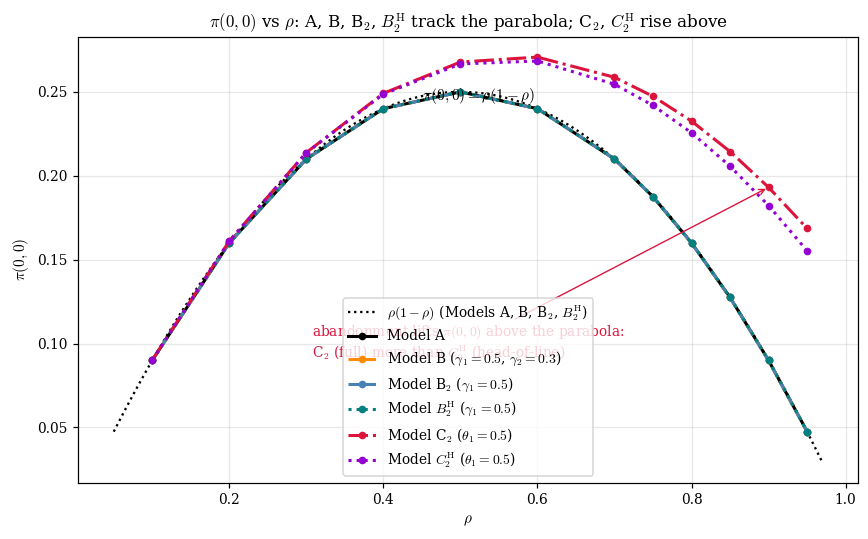

In [7]:

fig, ax = plt.subplots(figsize=(8, 5))
rr = np.linspace(0.05, 0.97, 200)
ax.plot(rr, rr*(1-rr), ":", color="black", lw=1.5,
        label=r"$\rho(1-\rho)$ (Models A, B, B$_2$, $B_2^{\mathrm{H}}$)")
for m,(c,ls,lab) in SWEEP_STYLE.items():
    ax.plot(rho_arr, sweep[m]["pi00"], ls, color=c, lw=2, marker="o", ms=4, label=lab)
ax.annotate("abandonment lifts " r"$\pi(0,0)$ above the parabola:" "\n"
            r"C$_2$ (full) more than $C_2^{\mathrm{H}}$ (head-of-line)",
            xy=(0.90, np.interp(0.90, rho_arr, sweep["C2"]["pi00"])),
            xytext=(0.30, 0.28), textcoords="axes fraction", fontsize=9, color=C_C2,
            arrowprops=dict(arrowstyle="->", color=C_C2, lw=0.9))
ax.text(0.45, 0.245, r"$\pi(0,0)=\rho(1-\rho)$", fontsize=10, color="black")
ax.set_xlabel(r"$\rho$"); ax.set_ylabel(r"$\pi(0,0)$")
ax.set_title(r"$\pi(0,0)$ vs $\rho$: A, B, B$_2$, $B_2^{\mathrm{H}}$ track the parabola; "
             r"C$_2$, $C_2^{\mathrm{H}}$ rise above")
ax.legend(loc="best"); ax.grid(alpha=0.3)
fig.tight_layout()
savefig("fig_sweep_pi00_vs_rho")
plt.show()


### Table 2 — $E[N_1]$ and $E[W_1]$ at $\rho\in\{0.5,0.7,0.9\}$ (LaTeX, `tab:comp:EN_sweep`)

In [8]:

def at_rho(m, key, rho):
    return np.interp(rho, rho_arr, sweep[m][key])

rows_tab = []
for rho in (0.50, 0.70, 0.90):
    rows_tab.append((rho,
        at_rho("A","En1",rho), at_rho("B2","En1",rho), at_rho("C2","En1",rho),
        at_rho("A","Ew1",rho), at_rho("B2","Ew1",rho), at_rho("C2","Ew1",rho)))

tab = []
tab.append(r"\begin{table}[t]\centering")
tab.append(r"\caption{Class-1 mean queue length $E[N_1]$ and waiting time "
           r"$E[W_1]$ under Models A, B$_2$ ($\gamma_1=0.5$) and C$_2$ ($\theta_1=0.5$), "
           r"with $\mu=1$ and $\lambda_1{:}\lambda_2=3{:}4$.}")
tab.append(r"\label{tab:comp:EN_sweep}")
tab.append(r"\begin{tabular}{lrrrrrr}")
tab.append(r"\toprule")
tab.append(r" & \multicolumn{3}{c}{$E[N_1]$} & \multicolumn{3}{c}{$E[W_1]$} \\")
tab.append(r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}")
tab.append(r"$\rho$ & A & B$_2$ & C$_2$ & A & B$_2$ & C$_2$ \\")
tab.append(r"\midrule")
for rho,a1,b1,c1,a2,b2,c2 in rows_tab:
    tab.append(f"{rho:.2f} & {a1:.4f} & {b1:.4f} & {c1:.4f} & "
               f"{a2:.4f} & {b2:.4f} & {c2:.4f} \\\\")
tab.append(r"\bottomrule")
tab.append(r"\end{tabular}")
tab.append(r"\end{table}")
table2 = "\n".join(tab)
print(table2)
with open(os.path.join(SAVE_DIR, "tab_EN_sweep.tex"), "w") as f:
    f.write(table2 + "\n")
print("\nsaved:", os.path.abspath(os.path.join(SAVE_DIR, "tab_EN_sweep.tex")))


\begin{table}[t]\centering
\caption{Class-1 mean queue length $E[N_1]$ and waiting time $E[W_1]$ under Models A, B$_2$ ($\gamma_1=0.5$) and C$_2$ ($\theta_1=0.5$), with $\mu=1$ and $\lambda_1{:}\lambda_2=3{:}4$.}
\label{tab:comp:EN_sweep}
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{3}{c}{$E[N_1]$} & \multicolumn{3}{c}{$E[W_1]$} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
$\rho$ & A & B$_2$ & C$_2$ & A & B$_2$ & C$_2$ \\
\midrule
0.50 & 0.1364 & 0.0767 & 0.0712 & 0.6364 & 0.3578 & 0.3323 \\
0.70 & 0.3000 & 0.1545 & 0.1392 & 1.0000 & 0.5151 & 0.4639 \\
0.90 & 0.5651 & 0.2626 & 0.2292 & 1.4651 & 0.6808 & 0.5941 \\
\bottomrule
\end{tabular}
\end{table}

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/tab_EN_sweep.tex


## Section 3 — Jockeying effect analysis (Model B₂)

**Theorem reference:** Theorem B₂ (integral-form $P(x,y)$); Corollary A
($\pi(0,0)=\rho(1-\rho)$ for **all** $\gamma_1$ — jockeying conserves the customer count $N$).

Fix $\lambda_1=0.3,\lambda_2=0.4,\mu=1$ ($\rho=0.70$). Sweep
$\gamma_1\in\{10^{-3},\dots,50\}$; the smallest value is the $\gamma_1\to0$ (Model A) reference.

### [Model B₂ — Theorem B₂ / Corollary A]
**Statement:** one-way jockeying $1\!\to\!2$ at rate $\gamma_1$ redistributes $N_1,N_2$
but conserves $N$; hence $E[N]$ and $\pi(0,0)=\rho(1-\rho)$ are $\gamma_1$-invariant.
**Validation method:** CTMC exact solver. **Parameters:** $\mu=1,\lambda_1=0.3,\lambda_2=0.4$.

In [9]:

GAMMA1_VALS = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0])
b2 = {k: [] for k in ("En1","En2","En","pi0","pi00","Ew1","Ew2")}
for g1 in GAMMA1_VALS:
    p = Params(LAM1_STD, LAM2_STD, MU, gamma1=float(g1))
    r, d, nm, tail = solve_adaptive(p, N_max=60, cap=100)
    Ew1, Ew2 = EW1_EW2(p, r["pi_joint"])
    b2["En1"].append(d["E_n1"]); b2["En2"].append(d["E_n2"]); b2["En"].append(d["E_n"])
    b2["pi0"].append(r["pi_idle"]); b2["pi00"].append(r["pi_joint"][0,0])
    b2["Ew1"].append(Ew1); b2["Ew2"].append(Ew2)
b2 = {k: np.array(v) for k, v in b2.items()}

# Model A reference (gamma1 -> 0)
rA, dA, _, _ = solve_adaptive(Params(LAM1_STD, LAM2_STD, MU))
RHO_STD = (LAM1_STD + LAM2_STD)/MU
print(f"Model A reference: E[N1]={dA['E_n1']:.4f}  E[N2]={dA['E_n2']:.4f}  "
      f"E[N]={dA['E_n']:.4f}  pi(0,0)={rA['pi_joint'][0,0]:.4f} (=rho(1-rho)={RHO_STD*(1-RHO_STD):.4f})")


Model A reference: E[N1]=0.3000  E[N2]=1.3333  E[N]=1.6333  pi(0,0)=0.2100 (=rho(1-rho)=0.2100)


### Figure 3a — $E[N_1],E[N_2]$; conservation of $E[N]$; invariance of $\pi(0,0)$

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_B2_jockeying_EN_vs_gamma1.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_B2_jockeying_EN_vs_gamma1.png


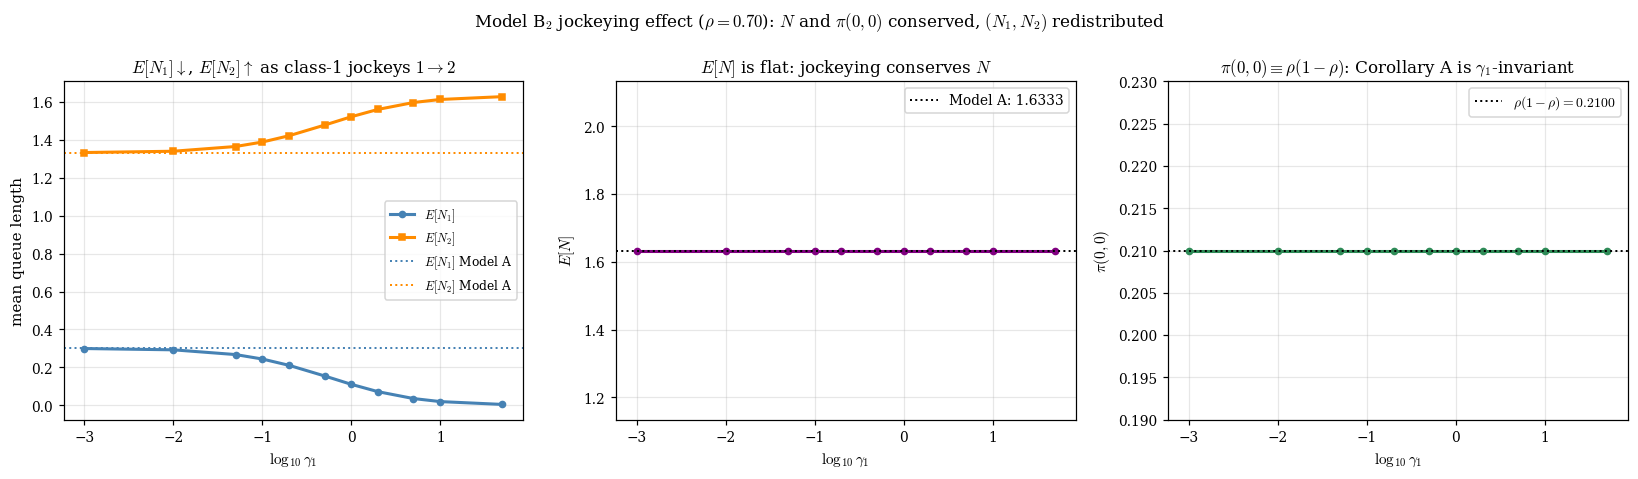

In [10]:

lg = np.log10(GAMMA1_VALS)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

ax[0].plot(lg, b2["En1"], "o-", color=C_B2, lw=2, ms=4, label=r"$E[N_1]$")
ax[0].plot(lg, b2["En2"], "s-", color="darkorange", lw=2, ms=4, label=r"$E[N_2]$")
ax[0].axhline(dA["E_n1"], color=C_B2, ls=":", lw=1.3, label=r"$E[N_1]$ Model A")
ax[0].axhline(dA["E_n2"], color="darkorange", ls=":", lw=1.3, label=r"$E[N_2]$ Model A")
ax[0].set_xlabel(r"$\log_{10}\gamma_1$"); ax[0].set_ylabel("mean queue length")
ax[0].set_title(r"$E[N_1]\downarrow$, $E[N_2]\uparrow$ as class-1 jockeys $1\to2$")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(lg, b2["En"], "o-", color="purple", lw=2, ms=4)
ax[1].axhline(dA["E_n"], color="black", ls=":", lw=1.3, label=rf"Model A: {dA['E_n']:.4f}")
ax[1].set_ylim(dA["E_n"]-0.5, dA["E_n"]+0.5)
ax[1].set_xlabel(r"$\log_{10}\gamma_1$"); ax[1].set_ylabel(r"$E[N]$")
ax[1].set_title(r"$E[N]$ is flat: jockeying conserves $N$")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)

ax[2].plot(lg, b2["pi00"], "o-", color="seagreen", lw=2, ms=4)
ax[2].axhline(RHO_STD*(1-RHO_STD), color="black", ls=":", lw=1.3,
              label=rf"$\rho(1-\rho)={RHO_STD*(1-RHO_STD):.4f}$")
ax[2].set_ylim(RHO_STD*(1-RHO_STD)-0.02, RHO_STD*(1-RHO_STD)+0.02)
ax[2].set_xlabel(r"$\log_{10}\gamma_1$"); ax[2].set_ylabel(r"$\pi(0,0)$")
ax[2].set_title(r"$\pi(0,0)\equiv\rho(1-\rho)$: Corollary A is $\gamma_1$-invariant")
ax[2].legend(fontsize=9); ax[2].grid(alpha=0.3)

fig.suptitle(r"Model B$_2$ jockeying effect ($\rho=0.70$): $N$ and $\pi(0,0)$ conserved, "
             r"$(N_1,N_2)$ redistributed", fontsize=11)
fig.tight_layout()
savefig("fig_B2_jockeying_EN_vs_gamma1")
plt.show()


### Figure 3b — priority advantage ratio $E[W_1]/E[W_2]$ vs $\gamma_1$

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_B2_priority_ratio_vs_gamma1.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_B2_priority_ratio_vs_gamma1.png


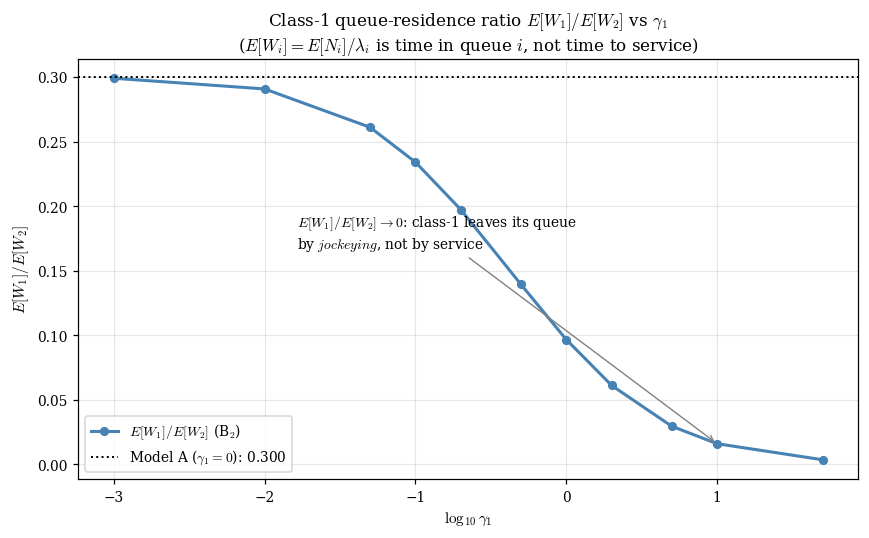

In [11]:

fig, ax = plt.subplots(figsize=(8, 5))
ratio = b2["Ew1"] / b2["Ew2"]
ax.plot(lg, ratio, "o-", color=C_B2, lw=2, ms=5, label=r"$E[W_1]/E[W_2]$ (B$_2$)")
A_ratio = (dA["E_n1"]/LAM1_STD) / (dA["E_n2"]/LAM2_STD)
ax.axhline(A_ratio, color=C_A, ls=":", lw=1.3, label=rf"Model A ($\gamma_1=0$): {A_ratio:.3f}")
ax.annotate(r"$E[W_1]/E[W_2]\to0$: class-1 leaves its queue" "\n"
            r"by $jockeying$, not by service",
            xy=(lg[-2], ratio[-2]), xytext=(0.28, 0.55), textcoords="axes fraction",
            fontsize=9, arrowprops=dict(arrowstyle="->", color="grey", lw=0.9))
ax.set_xlabel(r"$\log_{10}\gamma_1$"); ax.set_ylabel(r"$E[W_1]/E[W_2]$")
ax.set_title(r"Class-1 queue-residence ratio $E[W_1]/E[W_2]$ vs $\gamma_1$"
             "\n" r"($E[W_i]=E[N_i]/\lambda_i$ is time in queue $i$, not time to service)")
ax.legend(loc="best"); ax.grid(alpha=0.3)
fig.tight_layout()
savefig("fig_B2_priority_ratio_vs_gamma1")
plt.show()


### Figure 3c — class asymmetry $\times$ jockeying: $E[N_1],E[N_2]$ vs $\alpha=\lambda_1/(\lambda_1+\lambda_2)$

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_B2_class_asymmetry_gamma1.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_B2_class_asymmetry_gamma1.png


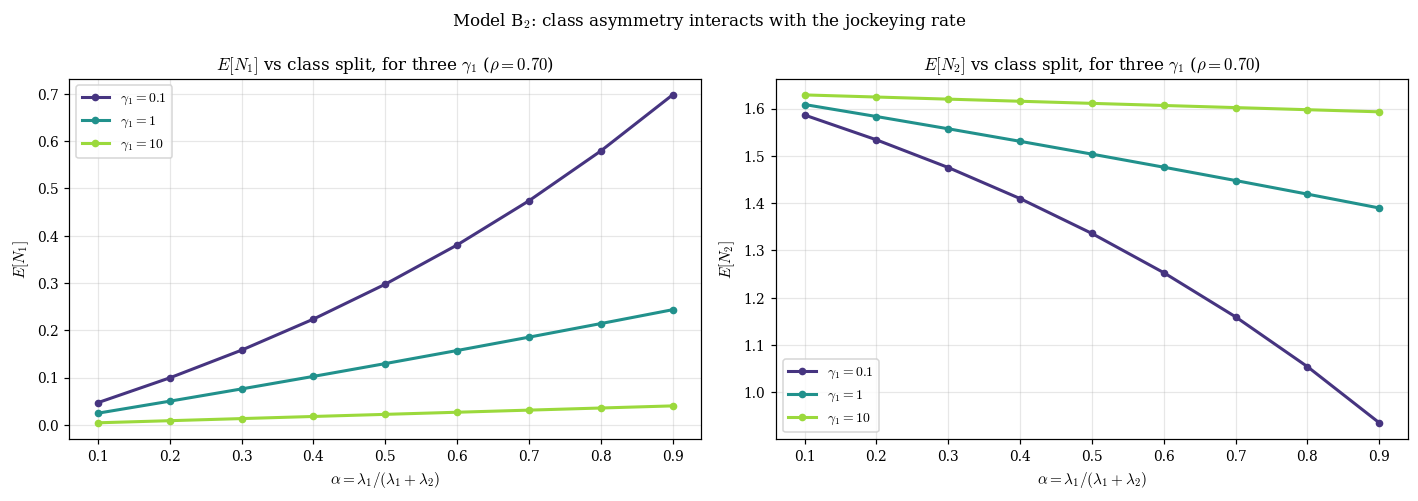

In [12]:

ALPHAS = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
G_SHOW = [0.1, 1.0, 10.0]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(G_SHOW)))
for col, g1 in zip(cmap, G_SHOW):
    e1, e2 = [], []
    for a in ALPHAS:
        l1, l2 = a*RHO_STD*MU, (1-a)*RHO_STD*MU
        p = Params(l1, l2, MU, gamma1=g1)
        r, d, _, _ = solve_adaptive(p, N_max=60, cap=100)
        e1.append(d["E_n1"]); e2.append(d["E_n2"])
    ax[0].plot(ALPHAS, e1, "o-", color=col, lw=2, ms=4, label=rf"$\gamma_1={g1:g}$")
    ax[1].plot(ALPHAS, e2, "o-", color=col, lw=2, ms=4, label=rf"$\gamma_1={g1:g}$")
ax[0].set_xlabel(r"$\alpha=\lambda_1/(\lambda_1+\lambda_2)$"); ax[0].set_ylabel(r"$E[N_1]$")
ax[0].set_title(r"$E[N_1]$ vs class split, for three $\gamma_1$ ($\rho=0.70$)")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel(r"$\alpha=\lambda_1/(\lambda_1+\lambda_2)$"); ax[1].set_ylabel(r"$E[N_2]$")
ax[1].set_title(r"$E[N_2]$ vs class split, for three $\gamma_1$ ($\rho=0.70$)")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle(r"Model B$_2$: class asymmetry interacts with the jockeying rate", fontsize=11)
fig.tight_layout()
savefig("fig_B2_class_asymmetry_gamma1")
plt.show()


## Section 4 — Abandonment effect analysis (Model C₂)

**Theorem reference:** Theorem C₂ (integral-form $P(x,y)$); Corollary C₂
($\pi_0,\pi(0,0)$ via $E[B_C]$, the mean class-1 busy period of the $M/M/1{+}M$ subsystem,
expressed through Kummer's ${}_1F_1$). Fix $\lambda_1=0.3,\lambda_2=0.4,\mu=1$; sweep
$\theta_1\in\{10^{-3},\dots,50\}$. With $\theta_1>0$ the chain is positive recurrent for
all loads.

### [Model C₂ — Theorem/Corollary C₂]
**Statement:** class-1 abandonment at rate $\theta_1$ bounds $E[N_1]$, lifts $\pi_0$ above
$1-\rho$, and trades throughput for shorter queues. **Validation method:** CTMC exact solver
+ closed-form $E[B_C]$ via `scipy.special.hyp1f1`. **Parameters:** $\mu=1,\lambda_1=0.3,\lambda_2=0.4$.

In [13]:

THETA1_VALS = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0])
c2 = {k: [] for k in ("En1","En2","En","pi0","pi00","Ew1","Ew2","thr","aban")}
for th in THETA1_VALS:
    p = Params(LAM1_STD, LAM2_STD, MU, theta1=float(th))
    r, d, nm, tail = solve_adaptive(p, N_max=60, cap=100)
    Ew1, Ew2 = EW1_EW2(p, r["pi_joint"])
    c2["En1"].append(d["E_n1"]); c2["En2"].append(d["E_n2"]); c2["En"].append(d["E_n"])
    c2["pi0"].append(r["pi_idle"]); c2["pi00"].append(r["pi_joint"][0,0])
    c2["Ew1"].append(Ew1); c2["Ew2"].append(Ew2)
    c2["thr"].append(d["throughput"]); c2["aban"].append(d["abandonment_rate"])
c2 = {k: np.array(v) for k, v in c2.items()}
print("E[N2] monotone?", "increasing then decreasing" if
      (np.argmax(c2["En2"]) not in (0, len(c2["En2"])-1)) else "monotone")


E[N2] monotone? monotone


### Figure 4a — $E[N_1]$, $E[N_2]$, $\pi_0$, throughput/abandonment vs $\theta_1$

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_C2_abandonment_EN_vs_theta1.pdf


saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_C2_abandonment_EN_vs_theta1.png


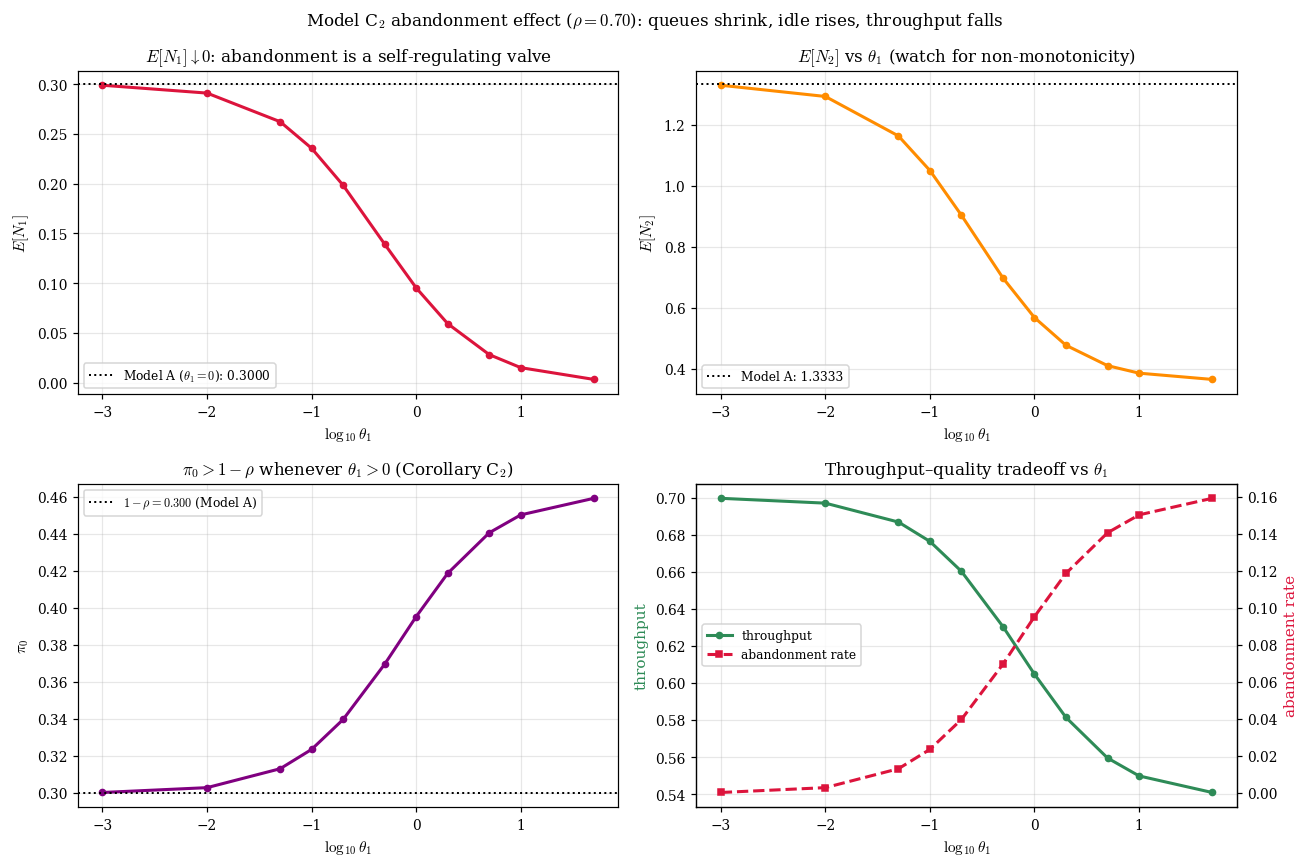

In [14]:

lt = np.log10(THETA1_VALS)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(lt, c2["En1"], "o-", color=C_C2, lw=2, ms=4)
ax[0,0].axhline(dA["E_n1"], color="black", ls=":", lw=1.3, label=rf"Model A ($\theta_1=0$): {dA['E_n1']:.4f}")
ax[0,0].set_xlabel(r"$\log_{10}\theta_1$"); ax[0,0].set_ylabel(r"$E[N_1]$")
ax[0,0].set_title(r"$E[N_1]\downarrow0$: abandonment is a self-regulating valve")
ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=0.3)

ax[0,1].plot(lt, c2["En2"], "o-", color="darkorange", lw=2, ms=4)
ax[0,1].axhline(dA["E_n2"], color="black", ls=":", lw=1.3, label=rf"Model A: {dA['E_n2']:.4f}")
imax = int(np.argmax(c2["En2"]))
if imax not in (0, len(c2["En2"])-1):
    ax[0,1].annotate("non-monotone:\nclass-1 exits free the\nserver for class-2",
                     xy=(lt[imax], c2["En2"][imax]), xytext=(0.1, 0.35),
                     textcoords="axes fraction", fontsize=8,
                     arrowprops=dict(arrowstyle="->", color="darkorange", lw=0.9))
ax[0,1].set_xlabel(r"$\log_{10}\theta_1$"); ax[0,1].set_ylabel(r"$E[N_2]$")
ax[0,1].set_title(r"$E[N_2]$ vs $\theta_1$ (watch for non-monotonicity)")
ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=0.3)

ax[1,0].plot(lt, c2["pi0"], "o-", color="purple", lw=2, ms=4)
ax[1,0].axhline(1-RHO_STD, color="black", ls=":", lw=1.3, label=rf"$1-\rho={1-RHO_STD:.3f}$ (Model A)")
ax[1,0].set_xlabel(r"$\log_{10}\theta_1$"); ax[1,0].set_ylabel(r"$\pi_0$")
ax[1,0].set_title(r"$\pi_0>1-\rho$ whenever $\theta_1>0$ (Corollary C$_2$)")
ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=0.3)

ax2 = ax[1,1]
ax2.plot(lt, c2["thr"], "o-", color="seagreen", lw=2, ms=4, label="throughput")
ax2b = ax2.twinx()
ax2b.plot(lt, c2["aban"], "s--", color=C_C2, lw=2, ms=4, label="abandonment rate")
ax2.set_xlabel(r"$\log_{10}\theta_1$"); ax2.set_ylabel("throughput", color="seagreen")
ax2b.set_ylabel("abandonment rate", color=C_C2)
ax2.set_title(r"Throughput–quality tradeoff vs $\theta_1$")
l1,la1 = ax2.get_legend_handles_labels(); l2,la2 = ax2b.get_legend_handles_labels()
ax2.legend(l1+l2, la1+la2, fontsize=8, loc="center left"); ax2.grid(alpha=0.3)

fig.suptitle(r"Model C$_2$ abandonment effect ($\rho=0.70$): queues shrink, "
             r"idle rises, throughput falls", fontsize=11)
fig.tight_layout()
savefig("fig_C2_abandonment_EN_vs_theta1")
plt.show()


### Figure 4b — mean class-1 busy period $E[B_C]$ vs $\theta_1$ (closed form via ${}_1F_1$)

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_C2_E_BC_vs_theta1.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_C2_E_BC_vs_theta1.png


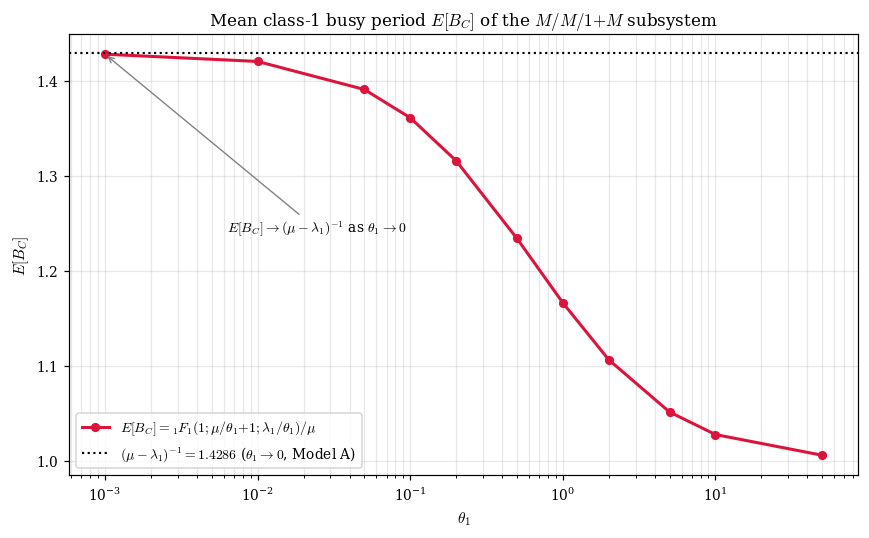

In [15]:

fig, ax = plt.subplots(figsize=(8, 5))
EBC = np.array([E_BC_value(LAM1_STD, MU, float(th)) for th in THETA1_VALS])
mask = np.isfinite(EBC)
ax.semilogx(THETA1_VALS[mask], EBC[mask], "o-", color=C_C2, lw=2, ms=5,
            label=r"$E[B_C]={}_1F_1(1;\mu/\theta_1{+}1;\lambda_1/\theta_1)/\mu$")
asymp = 1.0/(MU - LAM1_STD)
ax.axhline(asymp, color="black", ls=":", lw=1.4,
           label=rf"$(\mu-\lambda_1)^{{-1}}={asymp:.4f}$ ($\theta_1\to0$, Model A)")
ax.annotate(r"$E[B_C]\to(\mu-\lambda_1)^{-1}$ as $\theta_1\to0$",
            xy=(THETA1_VALS[mask][0], EBC[mask][0]), xytext=(0.2, 0.55),
            textcoords="axes fraction", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="grey", lw=0.9))
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$E[B_C]$")
ax.set_title(r"Mean class-1 busy period $E[B_C]$ of the $M/M/1{+}M$ subsystem")
ax.legend(loc="best"); ax.grid(alpha=0.3, which="both")
fig.tight_layout()
savefig("fig_C2_E_BC_vs_theta1")
plt.show()


### Figure 4c — heatmap $E[N_1]_{C_2}/E[N_1]_A$ over $(\rho,\theta_1)$

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_C2_rho_theta_heatmap.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_C2_rho_theta_heatmap.png


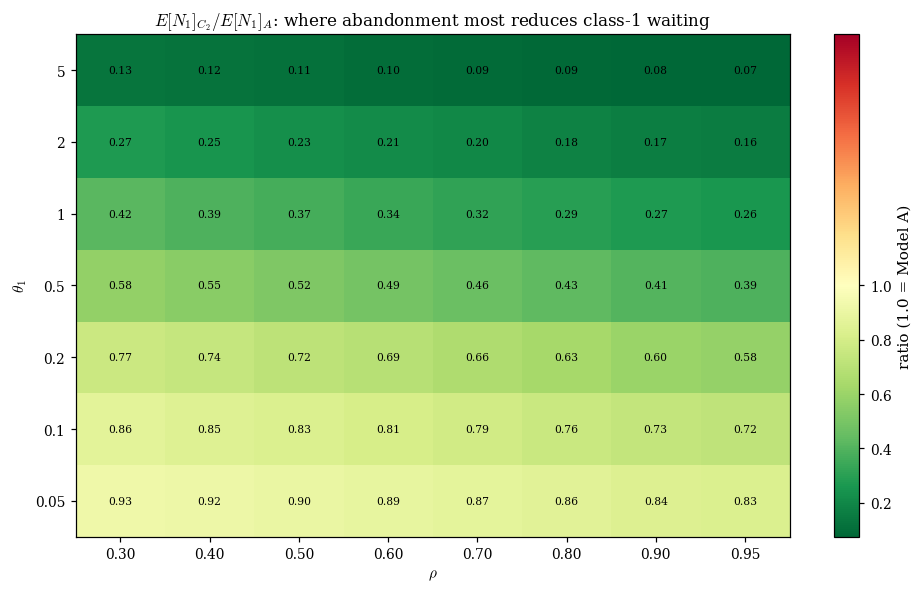

In [16]:

RHO_HM = np.array([0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95])
TH_HM  = np.array([0.05,0.1,0.2,0.5,1.0,2.0,5.0])
ratio_grid = np.full((len(TH_HM), len(RHO_HM)), np.nan)
for j, rho in enumerate(RHO_HM):
    l1, l2 = split_lams(rho)
    cap = 100 if rho <= 0.9 else 120
    tol = 1e-6 if rho >= 0.85 else 1e-8
    rA_loc, dA_loc, _, _ = solve_adaptive(Params(l1, l2, MU), N_max=60, tail_tol=tol, cap=cap)
    for i, th in enumerate(TH_HM):
        try:
            _, dC, _, _ = solve_adaptive(Params(l1, l2, MU, theta1=float(th)),
                                         N_max=60, tail_tol=tol, cap=cap)
            if dA_loc["E_n1"] > 1e-9:
                ratio_grid[i, j] = dC["E_n1"] / dA_loc["E_n1"]
        except (ValueError, RuntimeError):
            pass

fig, ax = plt.subplots(figsize=(9, 5.5))
vmin = np.nanmin(ratio_grid); vmax = max(np.nanmax(ratio_grid), 1.0 + 1e-6)
norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)
im = ax.imshow(ratio_grid, origin="lower", aspect="auto", cmap="RdYlGn_r", norm=norm)
ax.set_xticks(range(len(RHO_HM))); ax.set_xticklabels([f"{r:.2f}" for r in RHO_HM])
ax.set_yticks(range(len(TH_HM)));  ax.set_yticklabels([f"{t:g}" for t in TH_HM])
ax.set_xlabel(r"$\rho$"); ax.set_ylabel(r"$\theta_1$")
ax.set_title(r"$E[N_1]_{C_2}/E[N_1]_A$: where abandonment most reduces class-1 waiting")
for i in range(len(TH_HM)):
    for j in range(len(RHO_HM)):
        if np.isfinite(ratio_grid[i,j]):
            ax.text(j, i, f"{ratio_grid[i,j]:.2f}", ha="center", va="center",
                    fontsize=7, color="black")
plt.colorbar(im, ax=ax, label=r"ratio (1.0 = Model A)")
fig.tight_layout()
savefig("fig_C2_rho_theta_heatmap")
plt.show()


## Section 4b — Head-of-line versus full-rate mechanisms (Models $B_2^{\mathrm{H}}$, $C_2^{\mathrm{H}}$)

**Theorem reference:** Theorems/Corollaries for Models $B_2^{\mathrm{H}}$ and $C_2^{\mathrm{H}}$. The experiment
models replace the *length-proportional* mechanism rate of B₂/C₂
($\gamma_1 n_1$, $\theta_1 n_1$ — every waiting class-1 customer participates) by a
*head-of-line* rate ($\gamma_1\mathbf{1}_{\{n_1\geq1\}}$, $\theta_1\mathbf{1}_{\{n_1\geq1\}}$ —
only the customer at the head of Queue 1 jockeys/abandons). The aggregate class-1 outflow is
therefore **bounded by the single rate** $\gamma_1$ or $\theta_1$ instead of growing with the
queue, so the head-of-line mechanism is a strictly *weaker* drain of the priority queue. This
section quantifies that gap at fixed load $\rho=0.70$.

### [Comparative Analysis — head-of-line vs full-rate]
**Purpose:** isolate the effect of replacing $\gamma_1 n_1\to\gamma_1\mathbf{1}_{\{n_1\geq1\}}$
(jockeying) and $\theta_1 n_1\to\theta_1\mathbf{1}_{\{n_1\geq1\}}$ (abandonment).
**Models contrasted:** B₂ vs $B_2^{\mathrm{H}}$ (top), C₂ vs $C_2^{\mathrm{H}}$ (bottom).
**Expected behaviour:** the head-of-line drain is weaker, so $E[N_1]$ stays higher than under
the full rate; both jockeying models keep $\pi_0=1-\rho$; both abandonment models raise
$\pi_0$, C₂ more than $C_2^{\mathrm{H}}$. **Parameters:** $\mu=1,\lambda_1=0.3,\lambda_2=0.4$.

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_hol_vs_full.pdf


saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_hol_vs_full.png


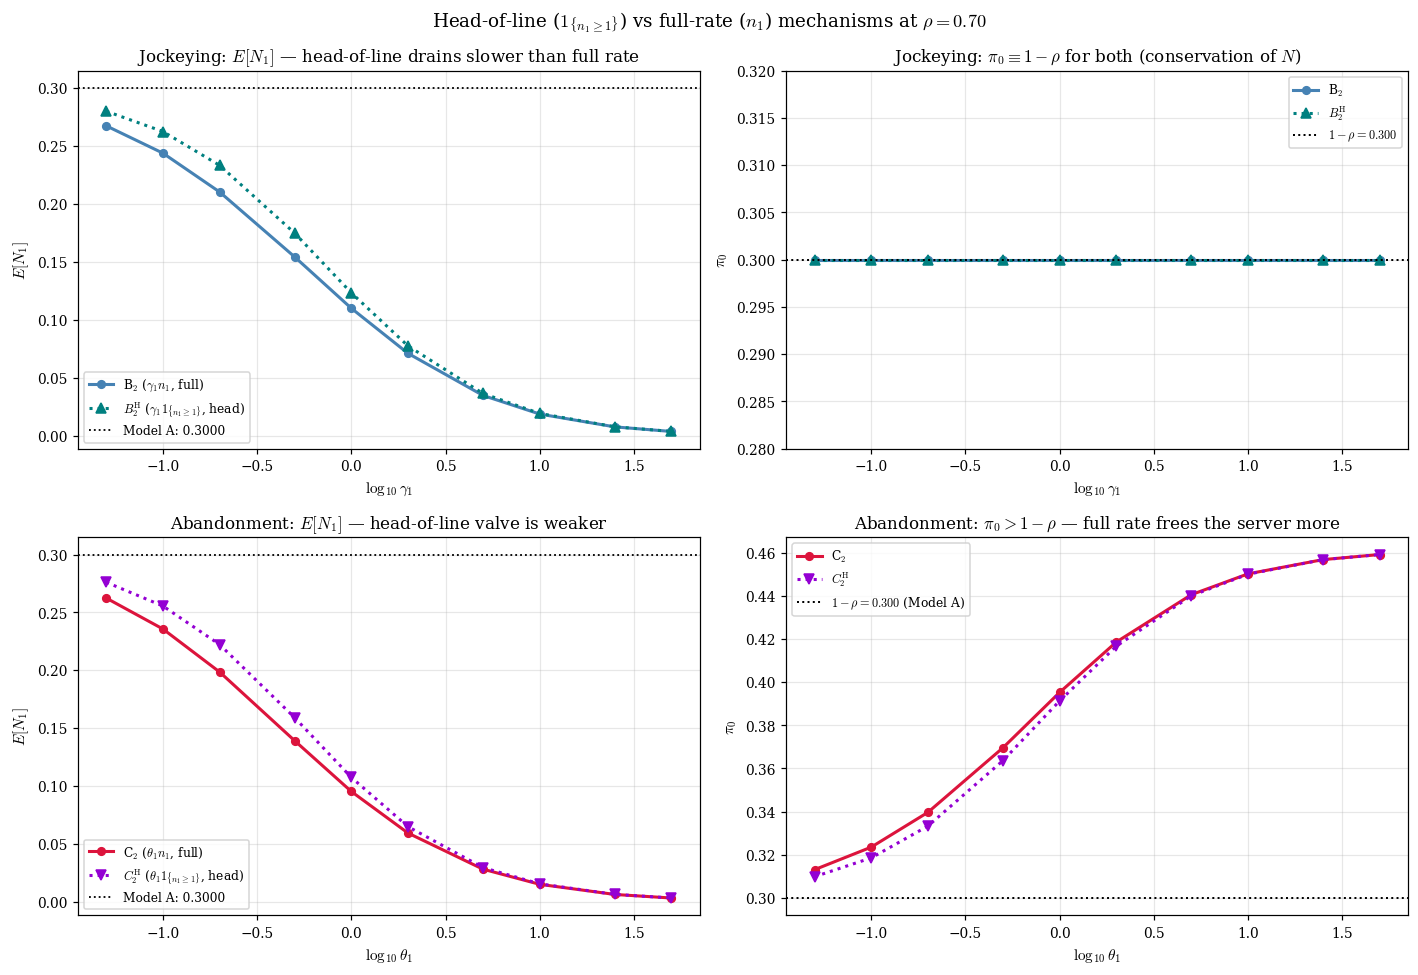

At rate 0.5:  E[N1]  B2=0.1545  B2^1=0.1750  C2=0.1392  C2^1=0.1591  (A=0.3000)
At rate 0.5:  pi0    C2=0.3696  C2^1=0.3636  (1-rho=0.3000)
At rate 5.0:  E[N1]  B2=0.0191  B2^1=0.0196  C2=0.0150  C2^1=0.0154


In [17]:

RATE_VALS = np.array([0.05,0.1,0.2,0.5,1.0,2.0,5.0,10.0,25.0,50.0])
hol = {m: {k: [] for k in ("En1","pi0")} for m in ("B2","B2^1","C2","C2^1")}
for rv in RATE_VALS:
    cfgs = {"B2":   Params(LAM1_STD, LAM2_STD, MU, gamma1=float(rv)),
            "B2^1": model_B21(LAM1_STD, LAM2_STD, MU, float(rv)),
            "C2":   Params(LAM1_STD, LAM2_STD, MU, theta1=float(rv)),
            "C2^1": model_C21(LAM1_STD, LAM2_STD, MU, float(rv))}
    for m, p in cfgs.items():
        r, d, _, _ = solve_adaptive(p, N_max=60, cap=100)
        hol[m]["En1"].append(d["E_n1"]); hol[m]["pi0"].append(r["pi_idle"])
for m in hol:
    for k in hol[m]: hol[m][k] = np.array(hol[m][k])
lr = np.log10(RATE_VALS)

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# Row 1 — jockeying: B2 (full) vs B2^1 (head-of-line)
ax[0,0].plot(lr, hol["B2"]["En1"],   "o-", color=C_B2,  lw=2, ms=5, label=r"B$_2$ ($\gamma_1 n_1$, full)")
ax[0,0].plot(lr, hol["B2^1"]["En1"], "^"+":", color=C_B21, lw=2, ms=6,
             label=r"$B_2^{\mathrm{H}}$ ($\gamma_1\mathbf{1}_{\{n_1\geq1\}}$, head)")
ax[0,0].axhline(dA["E_n1"], color="black", ls=":", lw=1.2, label=rf"Model A: {dA['E_n1']:.4f}")
ax[0,0].set_xlabel(r"$\log_{10}\gamma_1$"); ax[0,0].set_ylabel(r"$E[N_1]$")
ax[0,0].set_title(r"Jockeying: $E[N_1]$ — head-of-line drains slower than full rate")
ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=0.3)

ax[0,1].plot(lr, hol["B2"]["pi0"],   "o-", color=C_B2,  lw=2, ms=5, label=r"B$_2$")
ax[0,1].plot(lr, hol["B2^1"]["pi0"], "^"+":", color=C_B21, lw=2, ms=6, label=r"$B_2^{\mathrm{H}}$")
ax[0,1].axhline(1-RHO_STD, color="black", ls=":", lw=1.3, label=rf"$1-\rho={1-RHO_STD:.3f}$")
ax[0,1].set_ylim(1-RHO_STD-0.02, 1-RHO_STD+0.02)
ax[0,1].set_xlabel(r"$\log_{10}\gamma_1$"); ax[0,1].set_ylabel(r"$\pi_0$")
ax[0,1].set_title(r"Jockeying: $\pi_0\equiv1-\rho$ for both (conservation of $N$)")
ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=0.3)

# Row 2 — abandonment: C2 (full) vs C2^1 (head-of-line)
ax[1,0].plot(lr, hol["C2"]["En1"],   "o-", color=C_C2,  lw=2, ms=5, label=r"C$_2$ ($\theta_1 n_1$, full)")
ax[1,0].plot(lr, hol["C2^1"]["En1"], "v"+":", color=C_C21, lw=2, ms=6,
             label=r"$C_2^{\mathrm{H}}$ ($\theta_1\mathbf{1}_{\{n_1\geq1\}}$, head)")
ax[1,0].axhline(dA["E_n1"], color="black", ls=":", lw=1.2, label=rf"Model A: {dA['E_n1']:.4f}")
ax[1,0].set_xlabel(r"$\log_{10}\theta_1$"); ax[1,0].set_ylabel(r"$E[N_1]$")
ax[1,0].set_title(r"Abandonment: $E[N_1]$ — head-of-line valve is weaker")
ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=0.3)

ax[1,1].plot(lr, hol["C2"]["pi0"],   "o-", color=C_C2,  lw=2, ms=5, label=r"C$_2$")
ax[1,1].plot(lr, hol["C2^1"]["pi0"], "v"+":", color=C_C21, lw=2, ms=6, label=r"$C_2^{\mathrm{H}}$")
ax[1,1].axhline(1-RHO_STD, color="black", ls=":", lw=1.3, label=rf"$1-\rho={1-RHO_STD:.3f}$ (Model A)")
ax[1,1].set_xlabel(r"$\log_{10}\theta_1$"); ax[1,1].set_ylabel(r"$\pi_0$")
ax[1,1].set_title(r"Abandonment: $\pi_0>1-\rho$ — full rate frees the server more")
ax[1,1].legend(fontsize=8); ax[1,1].grid(alpha=0.3)

fig.suptitle(r"Head-of-line ($\mathbf{1}_{\{n_1\geq1\}}$) vs full-rate ($n_1$) mechanisms "
             r"at $\rho=0.70$", fontsize=12)
fig.tight_layout()
savefig("fig_hol_vs_full")
plt.show()

# quantitative read-outs for the thesis prose
i05 = int(np.argmin(np.abs(RATE_VALS - 0.5)))
print(f"At rate 0.5:  E[N1]  B2={hol['B2']['En1'][i05]:.4f}  B2^1={hol['B2^1']['En1'][i05]:.4f}  "
      f"C2={hol['C2']['En1'][i05]:.4f}  C2^1={hol['C2^1']['En1'][i05]:.4f}  (A={dA['E_n1']:.4f})")
print(f"At rate 0.5:  pi0    C2={hol['C2']['pi0'][i05]:.4f}  C2^1={hol['C2^1']['pi0'][i05]:.4f}  "
      f"(1-rho={1-RHO_STD:.4f})")
print(f"At rate 5.0:  E[N1]  B2={hol['B2']['En1'][-3]:.4f}  B2^1={hol['B2^1']['En1'][-3]:.4f}  "
      f"C2={hol['C2']['En1'][-3]:.4f}  C2^1={hol['C2^1']['En1'][-3]:.4f}")


## Section 5 — Convergence analysis (mathematical heart)

Direct validation of the limit theorems: C₂ $\to$ A as $\theta_1\to0$, B₂ $\to$ A as
$\gamma_1\to0$, and the B₂ instant-jockeying limit $\gamma_1\to\infty$. We measure the
$L_1$ distance of the joint distribution to Model A and fit log-log slopes.

### 5a. C₂ $\to$ A as $\theta_1\to0$
**Theorem reference:** Corollary C₂ limit — as $\theta_1\to0^+$, $E[B_C]\to(\mu-\lambda_1)^{-1}$,
hence $\pi_0\to1-\rho$ and $\pi(0,0)\to\rho(1-\rho)$ (Model A). **Validation:** CTMC $L_1$ distance.

In [18]:

theta1_conv = np.logspace(-3, 2, 40)
rA5, dA5, nmA5, _ = solve_adaptive(Params(LAM1_STD, LAM2_STD, MU), N_max=80, cap=100)
piA5 = rA5["pi_joint"]
L1_C2, dpi0_C2, dpi00_C2, dEn1_C2 = [], [], [], []
for th in theta1_conv:
    p = Params(LAM1_STD, LAM2_STD, MU, theta1=float(th))
    r, d, _, _ = solve_adaptive(p, N_max=80, cap=100)
    L1_C2.append(L1_distance(r["pi_joint"], piA5))
    dpi0_C2.append(abs(r["pi_idle"] - rA5["pi_idle"]))
    dpi00_C2.append(abs(r["pi_joint"][0,0] - piA5[0,0]))
    dEn1_C2.append(abs(d["E_n1"] - dA5["E_n1"]))
L1_C2, dpi0_C2, dpi00_C2, dEn1_C2 = map(np.array, (L1_C2, dpi0_C2, dpi00_C2, dEn1_C2))

def loglog_slope(x, y, xmax=1.0):
    m = (x < xmax) & (y > 0) & np.isfinite(y)
    if m.sum() < 2: return np.nan, (None, None)
    s, b = np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)
    return s, (s, b)

slope_L1_C2, fit_L1_C2 = loglog_slope(theta1_conv, L1_C2)
print(f"C2->A  L1 log-log slope (theta1<1): {slope_L1_C2:.3f}")


C2->A  L1 log-log slope (theta1<1): 0.847


### Figure 5a — $L_1$ convergence and $\pi_0,\pi(0,0)$ tracking (C₂ $\to$ A)

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_C2_to_A_L1.pdf


saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_C2_to_A_L1.png


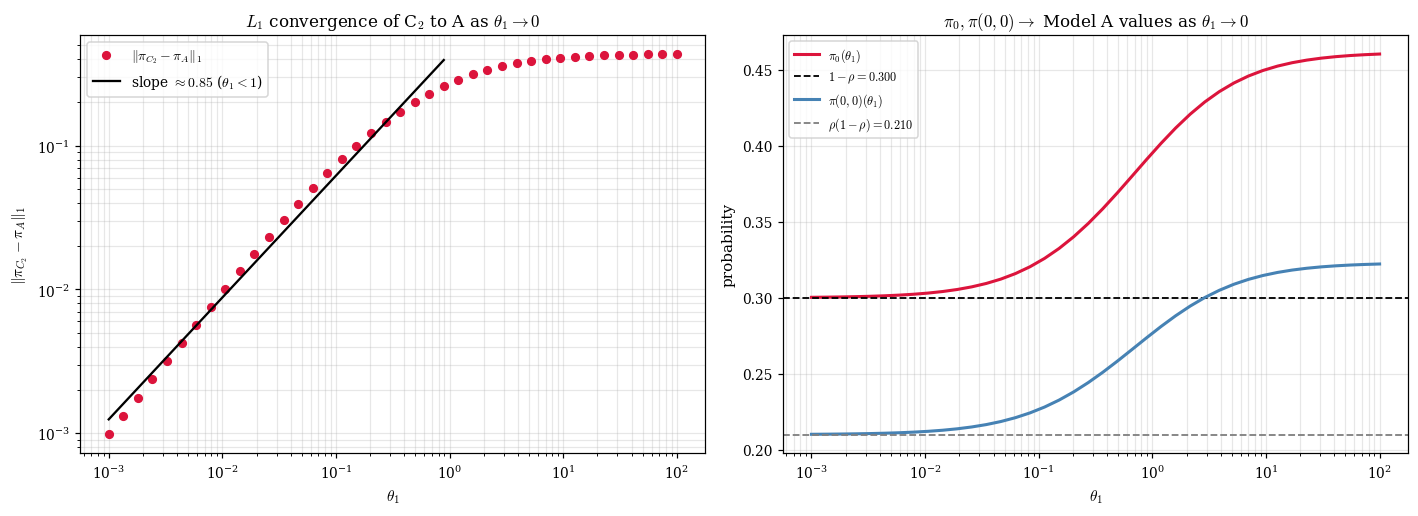

In [19]:

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
m = (L1_C2 > 0)
ax[0].loglog(theta1_conv[m], L1_C2[m], "o", color=C_C2, ms=5, label=r"$\|\pi_{C_2}-\pi_A\|_1$")
s, b = fit_L1_C2
xs = theta1_conv[(theta1_conv < 1) & m]
ax[0].loglog(xs, 10**(b)*xs**s, "-", color="black", lw=1.5,
             label=rf"slope $\approx{s:.2f}$ ($\theta_1<1$)")
ax[0].set_xlabel(r"$\theta_1$"); ax[0].set_ylabel(r"$\|\pi_{C_2}-\pi_A\|_1$")
ax[0].set_title(r"$L_1$ convergence of C$_2$ to A as $\theta_1\to0$")
ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

ax[1].semilogx(theta1_conv, [r for r in
               [solve_adaptive(Params(LAM1_STD,LAM2_STD,MU,theta1=float(t)),N_max=80,cap=100)[0]["pi_idle"]
                for t in theta1_conv]], "-", color=C_C2, lw=2, label=r"$\pi_0(\theta_1)$")
ax[1].axhline(1-RHO_STD, color="black", ls="--", lw=1.2, label=rf"$1-\rho={1-RHO_STD:.3f}$")
pi00_curve = [solve_adaptive(Params(LAM1_STD,LAM2_STD,MU,theta1=float(t)),N_max=80,cap=100)[0]["pi_joint"][0,0]
              for t in theta1_conv]
ax[1].semilogx(theta1_conv, pi00_curve, "-", color=C_B2, lw=2, label=r"$\pi(0,0)(\theta_1)$")
ax[1].axhline(RHO_STD*(1-RHO_STD), color="grey", ls="--", lw=1.2,
              label=rf"$\rho(1-\rho)={RHO_STD*(1-RHO_STD):.3f}$")
ax[1].set_xlabel(r"$\theta_1$"); ax[1].set_ylabel("probability")
ax[1].set_title(r"$\pi_0,\pi(0,0)\to$ Model A values as $\theta_1\to0$")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which="both")
fig.tight_layout()
savefig("fig_conv_C2_to_A_L1")
plt.show()


### Figure 5b — individual-metric convergence (C₂ $\to$ A) with fitted slopes

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_C2_to_A_indiv.pdf


saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_C2_to_A_indiv.png


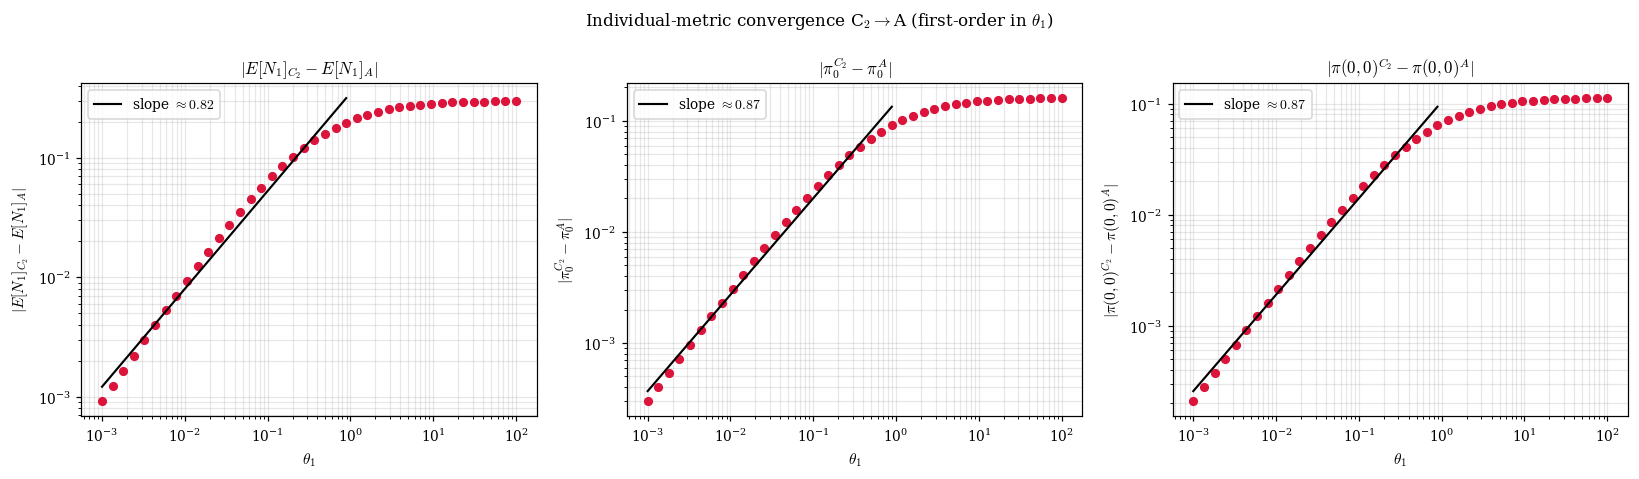

In [20]:

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
panels = [(dEn1_C2, r"$|E[N_1]_{C_2}-E[N_1]_A|$"),
          (dpi0_C2, r"$|\pi_0^{C_2}-\pi_0^A|$"),
          (dpi00_C2, r"$|\pi(0,0)^{C_2}-\pi(0,0)^A|$")]
for a, (yv, lab) in zip(ax, panels):
    mm = yv > 0
    a.loglog(theta1_conv[mm], yv[mm], "o", color=C_C2, ms=5)
    s, (ss, bb) = loglog_slope(theta1_conv, yv)
    if ss is not None:
        xs = theta1_conv[(theta1_conv < 1) & mm]
        a.loglog(xs, 10**bb * xs**ss, "-", color="black", lw=1.4, label=rf"slope $\approx{ss:.2f}$")
        a.legend()
    a.set_xlabel(r"$\theta_1$"); a.set_ylabel(lab); a.set_title(lab); a.grid(alpha=0.3, which="both")
fig.suptitle(r"Individual-metric convergence C$_2\to$A (first-order in $\theta_1$)", fontsize=11)
fig.tight_layout()
savefig("fig_conv_C2_to_A_indiv")
plt.show()


### 5b. B₂ $\to$ A as $\gamma_1\to0$
**Theorem reference:** the B₂ theorem reduces to Model A when $\gamma_1=0$. **Validation:** CTMC $L_1$ distance.

In [21]:

gamma1_conv = np.logspace(-3, 2, 40)
L1_B2, dpi0_B2, dpi00_B2, dEn1_B2 = [], [], [], []
for g in gamma1_conv:
    p = Params(LAM1_STD, LAM2_STD, MU, gamma1=float(g))
    r, d, _, _ = solve_adaptive(p, N_max=80, cap=100)
    L1_B2.append(L1_distance(r["pi_joint"], piA5))
    dpi0_B2.append(abs(r["pi_idle"] - rA5["pi_idle"]))
    dpi00_B2.append(abs(r["pi_joint"][0,0] - piA5[0,0]))
    dEn1_B2.append(abs(d["E_n1"] - dA5["E_n1"]))
L1_B2, dpi0_B2, dpi00_B2, dEn1_B2 = map(np.array, (L1_B2, dpi0_B2, dpi00_B2, dEn1_B2))
slope_L1_B2, fit_L1_B2 = loglog_slope(gamma1_conv, L1_B2)
slope_pi0_B2, _  = loglog_slope(gamma1_conv, dpi0_B2)
slope_pi00_B2, _ = loglog_slope(gamma1_conv, dpi00_B2)
slope_pi0_C2, _  = loglog_slope(theta1_conv, dpi0_C2)
slope_pi00_C2, _ = loglog_slope(theta1_conv, dpi00_C2)
print(f"B2->A  L1 log-log slope (gamma1<1): {slope_L1_B2:.3f}")
print("note: pi0,pi(0,0) are gamma1-invariant for B2, so their 'differences' are ~machine zero.")


B2->A  L1 log-log slope (gamma1<1): 0.873
note: pi0,pi(0,0) are gamma1-invariant for B2, so their 'differences' are ~machine zero.


### Figure 5c — $L_1$ convergence of B₂ to A as $\gamma_1\to0$

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_B2_to_A_L1.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_B2_to_A_L1.png


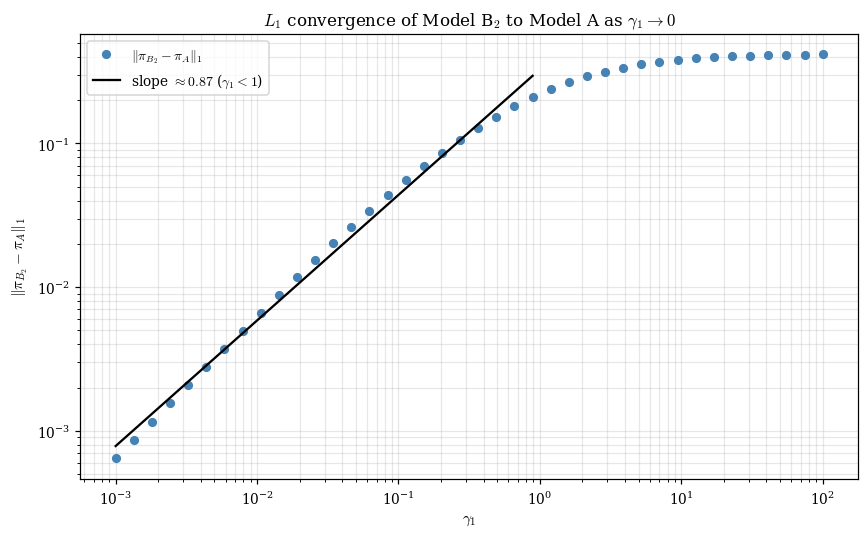

In [22]:

fig, ax = plt.subplots(figsize=(8, 5))
mm = L1_B2 > 0
ax.loglog(gamma1_conv[mm], L1_B2[mm], "o", color=C_B2, ms=5, label=r"$\|\pi_{B_2}-\pi_A\|_1$")
s, b = fit_L1_B2
xs = gamma1_conv[(gamma1_conv < 1) & mm]
ax.loglog(xs, 10**b * xs**s, "-", color="black", lw=1.5, label=rf"slope $\approx{s:.2f}$ ($\gamma_1<1$)")
ax.set_xlabel(r"$\gamma_1$"); ax.set_ylabel(r"$\|\pi_{B_2}-\pi_A\|_1$")
ax.set_title(r"$L_1$ convergence of Model B$_2$ to Model A as $\gamma_1\to0$")
ax.legend(); ax.grid(alpha=0.3, which="both")
fig.tight_layout()
savefig("fig_conv_B2_to_A_L1")
plt.show()


### 5c. B₂ instant-jockeying limit as $\gamma_1\to\infty$
**Mechanism.** Jockeying here is **one-way** ($1\!\to\!2$). As $\gamma_1\to\infty$ every
class-1 customer is converted to class-2 essentially on arrival, so the class-1 queue is
**drained**: $E[N_1]\to0$ and hence $E[N_1]/E[N_2]\to0$ (and $E[W_1]=E[N_1]/\lambda_1\to0$).
The total count $N$ is conserved by jockeying, so $E[N]$ stays at its Model-A value and all
of it accumulates in class-2: $E[N_2]\to E[N]_A$. (This is **not** the pooled-system limit
$\lambda_1/\lambda_2$, which would require two-way exchange; one-way jockeying is strictly
absorbing into class-2.)

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_B2_inf_jockeying.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_B2_inf_jockeying.png


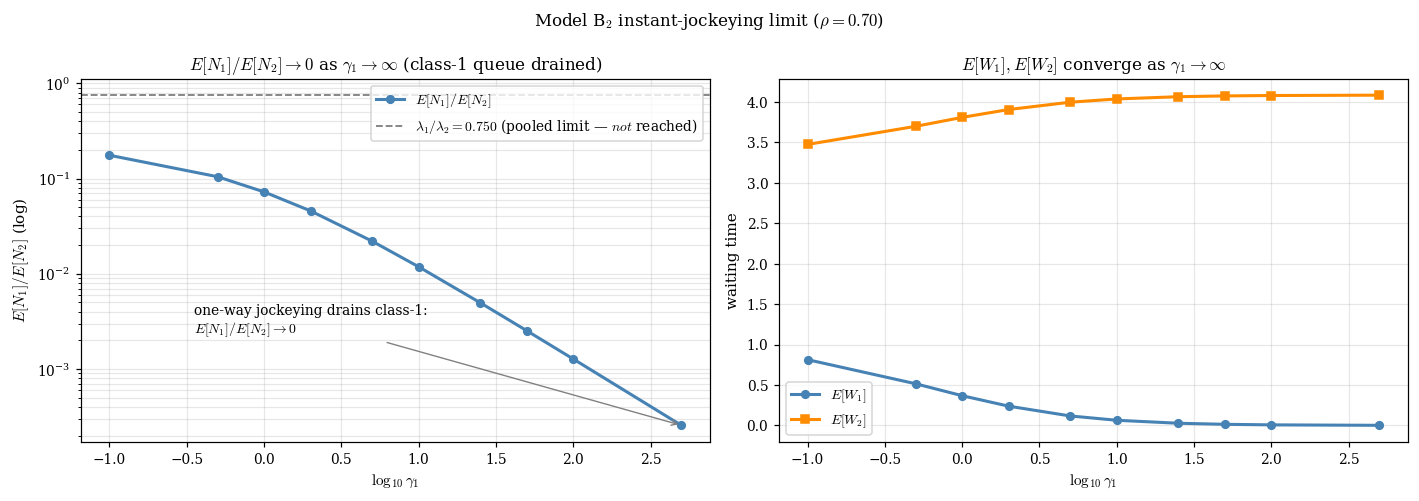

In [23]:

gamma1_inf = np.array([0.1,0.5,1.0,2.0,5.0,10.0,25.0,50.0,100.0,500.0])
ratio_inf, Ew1_inf, Ew2_inf = [], [], []
for g in gamma1_inf:
    p = Params(LAM1_STD, LAM2_STD, MU, gamma1=float(g))
    r, d, _, _ = solve_adaptive(p, N_max=60, cap=100)
    ratio_inf.append(d["E_n1"]/d["E_n2"] if d["E_n2"] > 1e-12 else np.nan)
    w1, w2 = EW1_EW2(p, r["pi_joint"]); Ew1_inf.append(w1); Ew2_inf.append(w2)
ratio_inf, Ew1_inf, Ew2_inf = map(np.array, (ratio_inf, Ew1_inf, Ew2_inf))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
lgi = np.log10(gamma1_inf)
ax[0].semilogy(lgi, ratio_inf, "o-", color=C_B2, lw=2, ms=5, label=r"$E[N_1]/E[N_2]$")
ax[0].axhline(LAM1_STD/LAM2_STD, color="grey", ls="--", lw=1.2,
              label=rf"$\lambda_1/\lambda_2={LAM1_STD/LAM2_STD:.3f}$ (pooled limit — $not$ reached)")
ax[0].annotate("one-way jockeying drains class-1:\n" r"$E[N_1]/E[N_2]\to0$",
               xy=(lgi[-1], ratio_inf[-1]), xytext=(0.18, 0.30),
               textcoords="axes fraction", fontsize=9,
               arrowprops=dict(arrowstyle="->", color="grey", lw=0.9))
ax[0].set_xlabel(r"$\log_{10}\gamma_1$"); ax[0].set_ylabel(r"$E[N_1]/E[N_2]$ (log)")
ax[0].set_title(r"$E[N_1]/E[N_2]\to0$ as $\gamma_1\to\infty$ (class-1 queue drained)")
ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

ax[1].plot(lgi, Ew1_inf, "o-", color=C_B2, lw=2, ms=5, label=r"$E[W_1]$")
ax[1].plot(lgi, Ew2_inf, "s-", color="darkorange", lw=2, ms=5, label=r"$E[W_2]$")
ax[1].set_xlabel(r"$\log_{10}\gamma_1$"); ax[1].set_ylabel("waiting time")
ax[1].set_title(r"$E[W_1],E[W_2]$ converge as $\gamma_1\to\infty$")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle(r"Model B$_2$ instant-jockeying limit ($\rho=0.70$)", fontsize=11)
fig.tight_layout()
savefig("fig_conv_B2_inf_jockeying")
plt.show()


### 5d. Experiment models $\to$ A: $B_2^{\mathrm{H}}$ as $\gamma_1\to0$, $C_2^{\mathrm{H}}$ as $\theta_1\to0$
**Theorem reference:** the $B_2^{\mathrm{H}}$ and $C_2^{\mathrm{H}}$ closed forms reduce to Model A as their
mechanism parameter $\to0$ (the kernel quadratic loses the $\gamma_1$/$\theta_1$ shift).
**Validation:** CTMC $L_1$ distance to Model A, with log-log slope. Reuses the Model-A
reference `piA5` and the grids `gamma1_conv`, `theta1_conv` from Section 5a/5b.

In [24]:

# B2^1 -> A as gamma1 -> 0 (head-of-line jockeying; conserves N like B2, so pi0/pi00 invariant)
L1_B21, dpi0_B21, dpi00_B21 = [], [], []
for g in gamma1_conv:
    p = model_B21(LAM1_STD, LAM2_STD, MU, float(g))
    r, d, _, _ = solve_adaptive(p, N_max=80, cap=100)
    L1_B21.append(L1_distance(r["pi_joint"], piA5))
    dpi0_B21.append(abs(r["pi_idle"] - rA5["pi_idle"]))
    dpi00_B21.append(abs(r["pi_joint"][0,0] - piA5[0,0]))
L1_B21, dpi0_B21, dpi00_B21 = map(np.array, (L1_B21, dpi0_B21, dpi00_B21))

# C2^1 -> A as theta1 -> 0 (head-of-line abandonment; pi0,pi00 vary)
L1_C21, dpi0_C21, dpi00_C21 = [], [], []
for th in theta1_conv:
    p = model_C21(LAM1_STD, LAM2_STD, MU, float(th))
    r, d, _, _ = solve_adaptive(p, N_max=80, cap=100)
    L1_C21.append(L1_distance(r["pi_joint"], piA5))
    dpi0_C21.append(abs(r["pi_idle"] - rA5["pi_idle"]))
    dpi00_C21.append(abs(r["pi_joint"][0,0] - piA5[0,0]))
L1_C21, dpi0_C21, dpi00_C21 = map(np.array, (L1_C21, dpi0_C21, dpi00_C21))

slope_L1_B21, fit_L1_B21 = loglog_slope(gamma1_conv, L1_B21)
slope_L1_C21, fit_L1_C21 = loglog_slope(theta1_conv, L1_C21)
slope_pi0_C21,  _ = loglog_slope(theta1_conv, dpi0_C21)
slope_pi00_C21, _ = loglog_slope(theta1_conv, dpi00_C21)
print(f"B2^1->A  L1 log-log slope (gamma1<1): {slope_L1_B21:.3f}")
print(f"C2^1->A  L1 log-log slope (theta1<1): {slope_L1_C21:.3f}")
print("note: B2^1 conserves N, so pi0,pi(0,0) are gamma1-invariant (deviations at machine floor).")


B2^1->A  L1 log-log slope (gamma1<1): 0.929
C2^1->A  L1 log-log slope (theta1<1): 0.903
note: B2^1 conserves N, so pi0,pi(0,0) are gamma1-invariant (deviations at machine floor).


### Figure 5d — $L_1$ convergence of $B_2^{\mathrm{H}}$ ($\gamma_1\to0$) and $C_2^{\mathrm{H}}$ ($\theta_1\to0$) to A

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_experiment_to_A.pdf


saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_conv_experiment_to_A.png


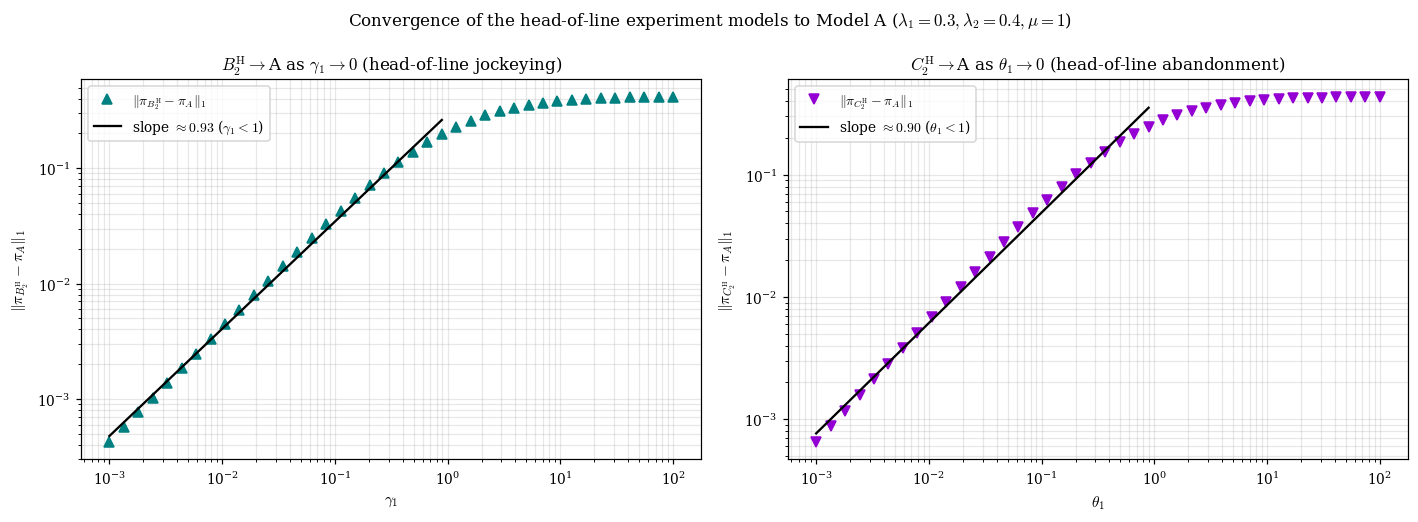

In [25]:

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

mB = L1_B21 > 0
ax[0].loglog(gamma1_conv[mB], L1_B21[mB], "^", color=C_B21, ms=6, label=r"$\|\pi_{B_2^{\mathrm{H}}}-\pi_A\|_1$")
s, b = fit_L1_B21
xs = gamma1_conv[(gamma1_conv < 1) & mB]
ax[0].loglog(xs, 10**b * xs**s, "-", color="black", lw=1.5, label=rf"slope $\approx{s:.2f}$ ($\gamma_1<1$)")
ax[0].set_xlabel(r"$\gamma_1$"); ax[0].set_ylabel(r"$\|\pi_{B_2^{\mathrm{H}}}-\pi_A\|_1$")
ax[0].set_title(r"$B_2^{\mathrm{H}}\to$A as $\gamma_1\to0$ (head-of-line jockeying)")
ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

mC = L1_C21 > 0
ax[1].loglog(theta1_conv[mC], L1_C21[mC], "v", color=C_C21, ms=6, label=r"$\|\pi_{C_2^{\mathrm{H}}}-\pi_A\|_1$")
s, b = fit_L1_C21
xs = theta1_conv[(theta1_conv < 1) & mC]
ax[1].loglog(xs, 10**b * xs**s, "-", color="black", lw=1.5, label=rf"slope $\approx{s:.2f}$ ($\theta_1<1$)")
ax[1].set_xlabel(r"$\theta_1$"); ax[1].set_ylabel(r"$\|\pi_{C_2^{\mathrm{H}}}-\pi_A\|_1$")
ax[1].set_title(r"$C_2^{\mathrm{H}}\to$A as $\theta_1\to0$ (head-of-line abandonment)")
ax[1].legend(); ax[1].grid(alpha=0.3, which="both")

fig.suptitle(r"Convergence of the head-of-line experiment models to Model A "
             r"($\lambda_1=0.3,\lambda_2=0.4,\mu=1$)", fontsize=11)
fig.tight_layout()
savefig("fig_conv_experiment_to_A")
plt.show()


## Section 6 — Class-asymmetry analysis

Fix $\rho=0.70,\mu=1$; vary $\alpha=\lambda_1/(\lambda_1+\lambda_2)$ with
$\lambda_1=\alpha\rho\mu$, $\lambda_2=(1-\alpha)\rho\mu$. Compare A, B₂ ($\gamma_1=0.5$),
C₂ ($\theta_1=0.5$).

### [Comparative Analysis — class asymmetry]
**Purpose:** how the priority benefit depends on the class mix. **Models contrasted:**
A, B₂, C₂. **Expected behaviour:** $E[W_1]/E[W_2]$ peaks at intermediate $\alpha$; B₂
shrinks the gap, C₂ reshapes it. **Parameters:** $\rho=0.70,\mu=1,\gamma_1=\theta_1=0.5$.

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_class_asymmetry.pdf


saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_class_asymmetry.png


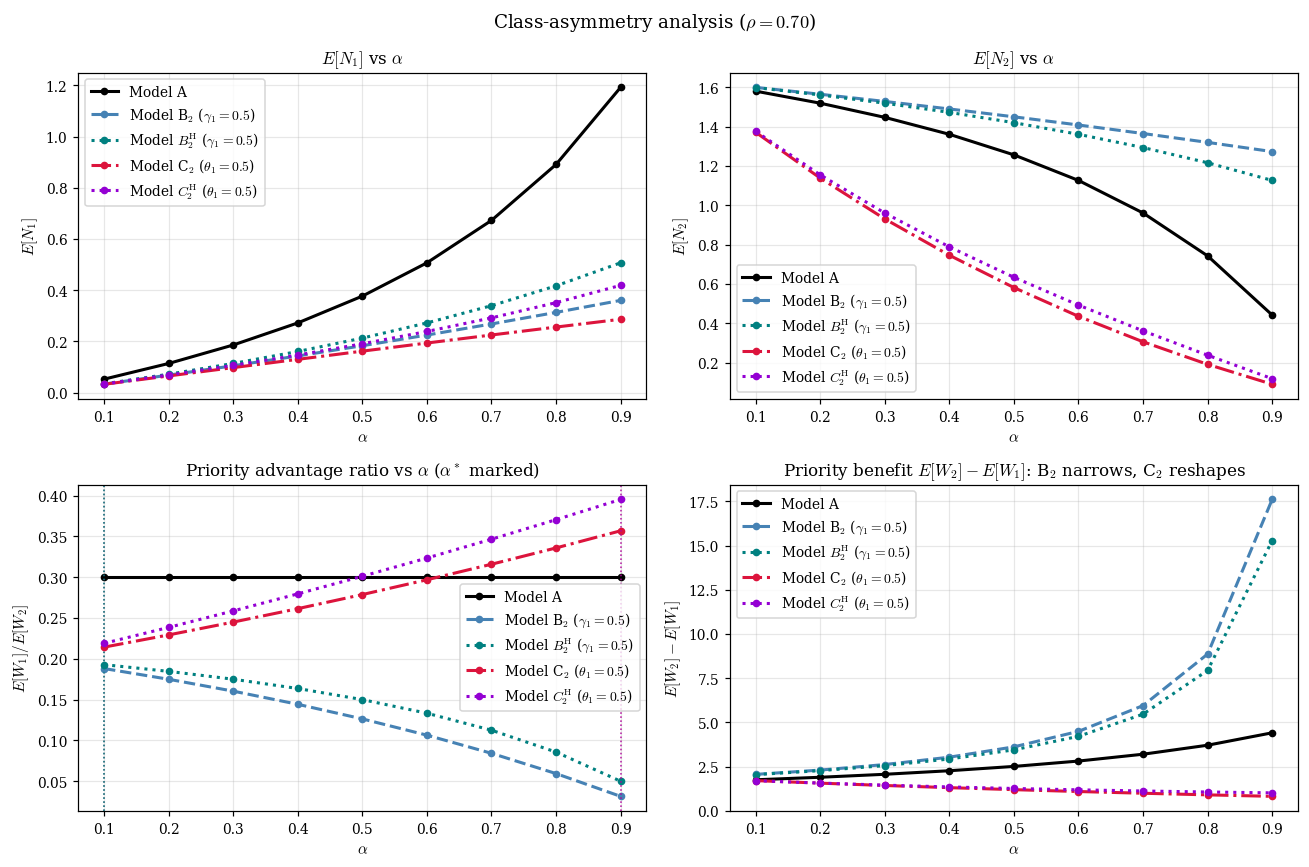

In [26]:

ALPHA6 = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
asym = {m: {k: [] for k in ("En1","En2","Ew1","Ew2")} for m in STYLE}
for a in ALPHA6:
    l1, l2 = a*RHO_STD*MU, (1-a)*RHO_STD*MU
    cfgs = {"A":   Params(l1,l2,MU),
            "B2":  Params(l1,l2,MU,gamma1=0.5),
            "B2^1":model_B21(l1,l2,MU,0.5),
            "C2":  Params(l1,l2,MU,theta1=0.5),
            "C2^1":model_C21(l1,l2,MU,0.5)}
    for m, p in cfgs.items():
        r, d, _, _ = solve_adaptive(p, N_max=60, cap=100)
        w1, w2 = EW1_EW2(p, r["pi_joint"])
        asym[m]["En1"].append(d["E_n1"]); asym[m]["En2"].append(d["E_n2"])
        asym[m]["Ew1"].append(w1); asym[m]["Ew2"].append(w2)
for m in asym:
    for k in asym[m]: asym[m][k] = np.array(asym[m][k])

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for m,(c,ls,lab) in STYLE.items():
    ax[0,0].plot(ALPHA6, asym[m]["En1"], ls, color=c, lw=2, marker="o", ms=4, label=lab)
ax[0,0].set_xlabel(r"$\alpha$"); ax[0,0].set_ylabel(r"$E[N_1]$")
ax[0,0].set_title(r"$E[N_1]$ vs $\alpha$"); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

for m,(c,ls,lab) in STYLE.items():
    ax[0,1].plot(ALPHA6, asym[m]["En2"], ls, color=c, lw=2, marker="o", ms=4, label=lab)
ax[0,1].set_xlabel(r"$\alpha$"); ax[0,1].set_ylabel(r"$E[N_2]$")
ax[0,1].set_title(r"$E[N_2]$ vs $\alpha$"); ax[0,1].legend(); ax[0,1].grid(alpha=0.3)

for m,(c,ls,lab) in STYLE.items():
    rr = asym[m]["Ew1"]/asym[m]["Ew2"]
    ax[1,0].plot(ALPHA6, rr, ls, color=c, lw=2, marker="o", ms=4, label=lab)
    astar = ALPHA6[int(np.argmax(rr))]
    ax[1,0].axvline(astar, color=c, ls=":", lw=1, alpha=0.6)
ax[1,0].set_xlabel(r"$\alpha$"); ax[1,0].set_ylabel(r"$E[W_1]/E[W_2]$")
ax[1,0].set_title(r"Priority advantage ratio vs $\alpha$ ($\alpha^\ast$ marked)")
ax[1,0].legend(); ax[1,0].grid(alpha=0.3)

for m,(c,ls,lab) in STYLE.items():
    benefit = asym[m]["Ew2"] - asym[m]["Ew1"]
    ax[1,1].plot(ALPHA6, benefit, ls, color=c, lw=2, marker="o", ms=4, label=lab)
ax[1,1].set_xlabel(r"$\alpha$"); ax[1,1].set_ylabel(r"$E[W_2]-E[W_1]$")
ax[1,1].set_title(r"Priority benefit $E[W_2]-E[W_1]$: B$_2$ narrows, C$_2$ reshapes")
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)

fig.suptitle(r"Class-asymmetry analysis ($\rho=0.70$)", fontsize=12)
fig.tight_layout()
savefig("fig_class_asymmetry")
plt.show()


## Section 7 — Comprehensive comparison tables (LaTeX → `.tex`)

Each table is printed to stdout and written to `figures/results/` as a `.tex` file for
direct `\input{}`.

### Table 7.1 — main comparison (`tab:comp:main`)

In [27]:

def metrics_at(p):
    r, d, _, _ = solve_adaptive(p, N_max=60, cap=120)
    w1, w2 = EW1_EW2(p, r["pi_joint"])
    return dict(En1=d["E_n1"], En2=d["E_n2"], En=d["E_n"], Ew1=w1, Ew2=w2,
                pi0=r["pi_idle"], pi00=r["pi_joint"][0,0])

lines = [r"\begin{table}[t]\centering",
         r"\caption{Comparison of Models $A$, $B$ ($\gamma_1=0.5$, $\gamma_2=0.3$), $B_2$ "
         r"and $\BH$ ($\gamma_1=0.5$), and $C_2$ and $\CH$ ($\theta_1=0.5$) at three "
         r"traffic intensities with $\lambda_1{:}\lambda_2=3{:}4$, $\mu=1$. The "
         r"head-of-line models $\BH$ and $\CH$ use the rate "
         r"$\gamma_1\mathbf{1}_{\{n_1\geq1\}}$, respectively "
         r"$\theta_1\mathbf{1}_{\{n_1\geq1\}}$; Model-$B_2$ and Model-$C_2$ use the full "
         r"rates $\gamma_1 n_1$ and $\theta_1 n_1$. Model-$B$, whose PGF remains open, "
         r"joins through its truncated-CTMC solution ---like every entry of this table--- "
         r"since no closed form is required for the comparison.}",
         r"\label{tab:comp:main}",
         r"\begin{tabular}{llrrrrrrr}", r"\toprule",
         r"$\rho$ & Model & $E[N_1]$ & $E[N_2]$ & $E[N]$ & $E[W_1]$ & $E[W_2]$ & $\pi_0$ & $\pi(0,0)$ \\",
         r"\midrule"]
for ri, rho in enumerate((0.50, 0.70, 0.90)):
    l1, l2 = split_lams(rho)
    mods = [("$A$", Params(l1,l2,MU)),
            ("$B$", Params(l1,l2,MU,gamma1=0.5,gamma2=0.3)),
            ("$B_2$", Params(l1,l2,MU,gamma1=0.5)),
            (r"$\BH$", model_B21(l1,l2,MU,0.5)),
            ("$C_2$", Params(l1,l2,MU,theta1=0.5)),
            (r"$\CH$", model_C21(l1,l2,MU,0.5))]
    for k,(name,p) in enumerate(mods):
        mm = metrics_at(p)
        rcell = rf"\multirow{{6}}{{*}}{{{rho:.2f}}}" if k == 0 else ""
        lines.append(f"{rcell} & {name} & {mm['En1']:.4f} & {mm['En2']:.4f} & {mm['En']:.4f} & "
                     f"{mm['Ew1']:.4f} & {mm['Ew2']:.4f} & {mm['pi0']:.4f} & {mm['pi00']:.4f} \\\\")
    if ri < 2: lines.append(r"\midrule")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
tab71 = "\n".join(lines)
print(tab71)
with open(os.path.join(SAVE_DIR, "tab_comparison_main.tex"), "w") as f: f.write(tab71+"\n")
print("\nsaved:", os.path.abspath(os.path.join(SAVE_DIR, "tab_comparison_main.tex")))


\begin{table}[t]\centering
\caption{Comparison of Models $A$, $B$ ($\gamma_1=0.5$, $\gamma_2=0.3$), $B_2$ and $\BH$ ($\gamma_1=0.5$), and $C_2$ and $\CH$ ($\theta_1=0.5$) at three traffic intensities with $\lambda_1{:}\lambda_2=3{:}4$, $\mu=1$. The head-of-line models $\BH$ and $\CH$ use the rate $\gamma_1\mathbf{1}_{\{n_1\geq1\}}$, respectively $\theta_1\mathbf{1}_{\{n_1\geq1\}}$; Model-$B_2$ and Model-$C_2$ use the full rates $\gamma_1 n_1$ and $\theta_1 n_1$. Model-$B$, whose PGF remains open, joins through its truncated-CTMC solution ---like every entry of this table--- since no closed form is required for the comparison.}
\label{tab:comp:main}
\begin{tabular}{llrrrrrrr}
\toprule
$\rho$ & Model & $E[N_1]$ & $E[N_2]$ & $E[N]$ & $E[W_1]$ & $E[W_2]$ & $\pi_0$ & $\pi(0,0)$ \\
\midrule
\multirow{6}{*}{0.50} & $A$ & 0.1364 & 0.3636 & 0.5000 & 0.6364 & 1.2727 & 0.5000 & 0.2500 \\
 & $B$ & 0.1665 & 0.3335 & 0.5000 & 0.7772 & 1.1671 & 0.5000 & 0.2500 \\
 & $B_2$ & 0.0767 & 0.4233 & 0.5000 &

### Table 7.2 — empirical convergence rates (`tab:conv:rates`)

In [ ]:

def _slp(s):
    return 'n/a' if not np.isfinite(s) else f'{s:.3f}'

lines = [r"\begin{table}[t]\centering",
         r"\caption{Empirical convergence rates of Models $C_2$, $\CH$, $B_2$ and $\BH$ "
         r"to Model-$A$, from log-log regression of the deviation against the mechanism "
         r"parameter (fit over parameter $<1$). The head-of-line models converge "
         r"at the same first order as their full-rate counterparts.}",
         r"\label{tab:conv:rates}",
         r"\begin{tabular}{llrrrl}", r"\toprule",
         r"Limit & Parameter & $L_1$ slope & $\pi_0$ slope & $\pi(0,0)$ slope & Valid range \\",
         r"\midrule",
         rf"C$_2\to$A & $\theta_1\to0$ & {slope_L1_C2:.3f} & {_slp(slope_pi0_C2)} & "
         rf"{_slp(slope_pi00_C2)} & $\theta_1\in[10^{{-3}},1)$ \\",
         rf"$\CH\to$A & $\theta_1\to0$ & {slope_L1_C21:.3f} & {_slp(slope_pi0_C21)} & "
         rf"{_slp(slope_pi00_C21)} & $\theta_1\in[10^{{-3}},1)$ \\",
         r"\midrule",
         rf"B$_2\to$A & $\gamma_1\to0$ & {slope_L1_B2:.3f} & {_slp(slope_pi0_B2)} & "
         rf"{_slp(slope_pi00_B2)} & $\gamma_1\in[10^{{-3}},1)$ \\",
         rf"$\BH\to$A & $\gamma_1\to0$ & {slope_L1_B21:.3f} & n/a & n/a & "
         rf"$\gamma_1\in[10^{{-3}},1)$ \\",
         r"\bottomrule", r"\end{tabular}",
         r"\footnotesize\par\vspace{2pt}For the jockeying models $B_2$ and $\BH$, $\pi_0$ "
         r"and $\pi(0,0)$ are $\gamma_1$-invariant (jockeying conserves $N$), so their "
         r"deviations sit at the numerical floor and the slope is not meaningful (n/a).",
         r"\end{table}"]
tab72 = "\n".join(lines)
print(tab72)
with open(os.path.join(SAVE_DIR, "tab_convergence_rates.tex"), "w") as f: f.write(tab72+"\n")
print("\nsaved:", os.path.abspath(os.path.join(SAVE_DIR, "tab_convergence_rates.tex")))


### Table 7.3 — priority benefit (`tab:prio:benefit`)

In [ ]:

lines = [r"\begin{table}[t]\centering",
         r"\caption{Class-1 mean waiting time $E[W_1]$ and priority ratio $E[W_2]/E[W_1]$ "
         r"under each model ($\lambda_1{:}\lambda_2=3{:}4$, $\mu=1$, $\gamma_1=\theta_1=0.5$).}",
         r"\label{tab:prio:benefit}",
         r"\begin{tabular}{lrrrrrr}", r"\toprule",
         r" & \multicolumn{2}{c}{Model-$A$} & \multicolumn{2}{c}{Model-$B_2$} & "
         r"\multicolumn{2}{c}{Model-$C_2$} \\",
         r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}",
         r"$\rho$ & $E[W_1]$ & $E[W_2]/E[W_1]$ & $E[W_1]$ & $E[W_2]/E[W_1]$ & "
         r"$E[W_1]$ & $E[W_2]/E[W_1]$ \\",
         r"\midrule"]
for rho in (0.50, 0.70, 0.90):
    l1, l2 = split_lams(rho)
    cells = []
    for p in (Params(l1,l2,MU), Params(l1,l2,MU,gamma1=0.5), Params(l1,l2,MU,theta1=0.5)):
        r, d, _, _ = solve_adaptive(p, N_max=60, cap=120)
        w1, w2 = EW1_EW2(p, r["pi_joint"])
        cells += [f"{w1:.4f}", f"{w2/w1:.4f}"]
    lines.append(f"{rho:.2f} & " + " & ".join(cells) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
tab73 = "\n".join(lines)
print(tab73)
with open(os.path.join(SAVE_DIR, "tab_priority_benefit.tex"), "w") as f: f.write(tab73+"\n")
print("\nsaved:", os.path.abspath(os.path.join(SAVE_DIR, "tab_priority_benefit.tex")))


## Section 8 — Simulation vs CTMC cross-validation

Discrete-event simulation ($5\times10^6$ events; lower precision than the CTMC) vs the exact
truncated CTMC for the three canonical configurations. Scatter of CTMC $\pi(n_1,n_2)$ vs the
empirical frequency should lie on $y=x$.

### [Cross-validation — simulation vs CTMC]
**Validation method:** event-driven `simulate` vs `solve_exact`.
**Parameters:** $\mu=1,\lambda_1=0.3,\lambda_2=0.4$; A, B₂ ($\gamma_1=0.5$), C₂ ($\theta_1=0.5$).

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_sim_vs_ctmc.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_sim_vs_ctmc.png


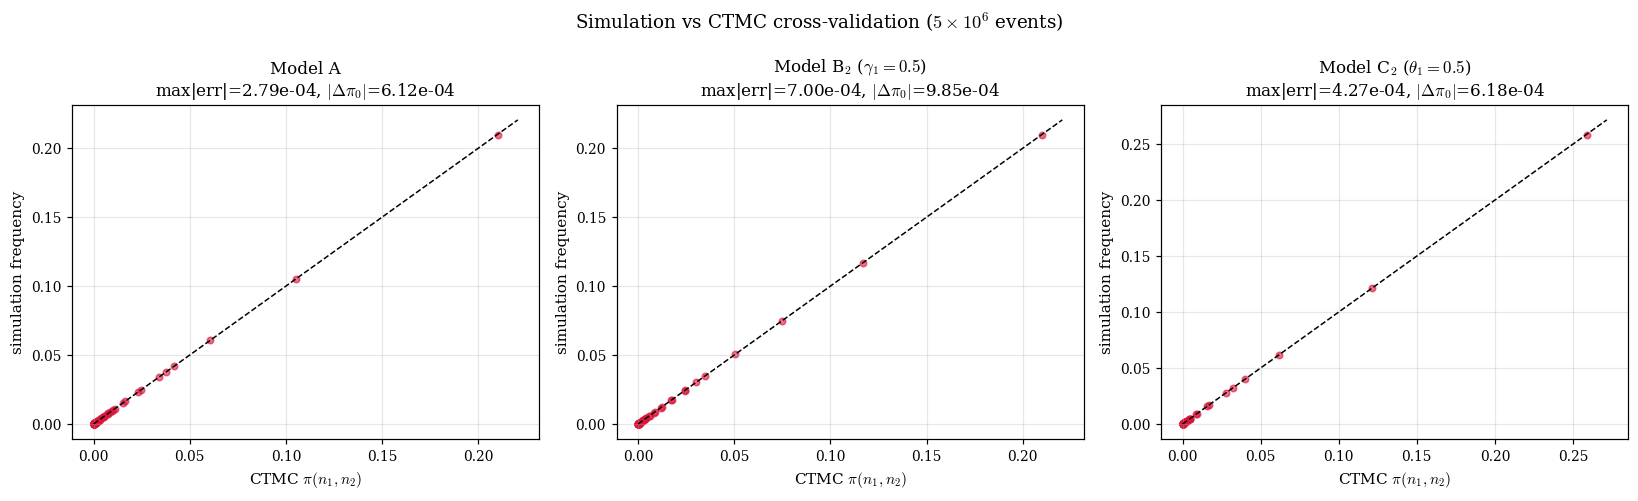

simulation/CTMC cross-validation passed (max abs error < 1e-2 for all models)


In [30]:

sim_cfgs = [("Model A",  Params(LAM1_STD, LAM2_STD, MU)),
            (r"Model B$_2$ ($\gamma_1=0.5$)", Params(LAM1_STD, LAM2_STD, MU, gamma1=0.5)),
            (r"Model C$_2$ ($\theta_1=0.5$)", Params(LAM1_STD, LAM2_STD, MU, theta1=0.5))]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for a, (name, p) in zip(ax, sim_cfgs):
    sim = simulate(p, n_events=5_000_000, seed=42)
    exact = solve_exact(p, N_max=50)
    M = min(sim["pi_joint"].shape[0], exact["pi_joint"].shape[0])
    pe = exact["pi_joint"][:M, :M]; ps = sim["pi_joint"][:M, :M]
    mask = pe > 1e-4
    max_err = float(np.abs(pe - ps).max())
    err_idle = abs(sim["pi_idle"] - exact["pi_idle"])
    a.scatter(pe[mask], ps[mask], s=18, color=C_C2, alpha=0.6)
    lim = max(pe[mask].max(), ps[mask].max()) * 1.05
    a.plot([0, lim], [0, lim], "k--", lw=1)
    a.set_xlabel(r"CTMC $\pi(n_1,n_2)$"); a.set_ylabel("simulation frequency")
    a.set_title(f"{name}\nmax|err|={max_err:.2e}, "+r"$|\Delta\pi_0|$="+f"{err_idle:.2e}")
    a.grid(alpha=0.3)
    assert max_err < 1e-2, f"sim/CTMC mismatch {name}: {max_err}"
fig.suptitle(r"Simulation vs CTMC cross-validation ($5\times10^6$ events)", fontsize=12)
fig.tight_layout()
savefig("fig_sim_vs_ctmc")
plt.show()
print("simulation/CTMC cross-validation passed (max abs error < 1e-2 for all models)")


### [Cross-validation — head-of-line experiment models]
The event-driven `simulate` and the truncated `solve_exact` both honour the head-of-line
flag `hol1` (the class-1 jockeying/abandonment rate is $\gamma_1\mathbf{1}_{\{n_1\geq1\}}$ /
$\theta_1\mathbf{1}_{\{n_1\geq1\}}$), so this is an independent check of the new CTMC.
**Parameters:** $\mu=1,\lambda_1=0.3,\lambda_2=0.4$; $B_2^{\mathrm{H}}$ ($\gamma_1=0.5$),
$C_2^{\mathrm{H}}$ ($\theta_1=0.5$).

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_sim_vs_ctmc_experiment.pdf
saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_sim_vs_ctmc_experiment.png


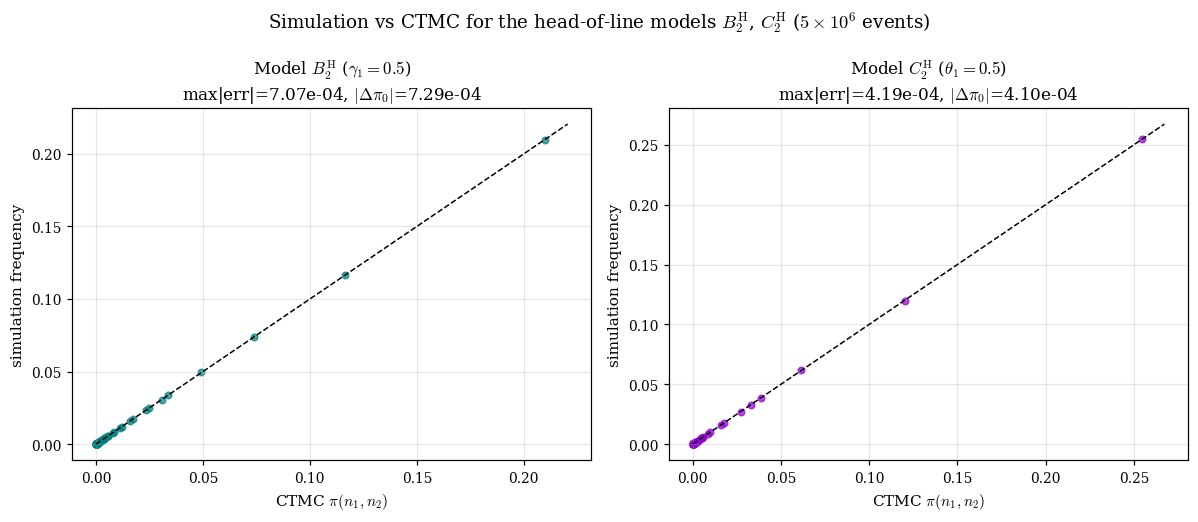

head-of-line simulation/CTMC cross-validation passed (max abs error < 1e-2)


In [31]:

sim_cfgs_exp = [(r"Model $B_2^{\mathrm{H}}$ ($\gamma_1=0.5$)", model_B21(LAM1_STD, LAM2_STD, MU, 0.5), C_B21),
                (r"Model $C_2^{\mathrm{H}}$ ($\theta_1=0.5$)", model_C21(LAM1_STD, LAM2_STD, MU, 0.5), C_C21)]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))
for a, (name, p, col) in zip(ax, sim_cfgs_exp):
    sim = simulate(p, n_events=5_000_000, seed=42)
    exact = solve_exact(p, N_max=50)
    M = min(sim["pi_joint"].shape[0], exact["pi_joint"].shape[0])
    pe = exact["pi_joint"][:M, :M]; ps = sim["pi_joint"][:M, :M]
    mask = pe > 1e-4
    max_err = float(np.abs(pe - ps).max())
    err_idle = abs(sim["pi_idle"] - exact["pi_idle"])
    a.scatter(pe[mask], ps[mask], s=18, color=col, alpha=0.7)
    lim = max(pe[mask].max(), ps[mask].max()) * 1.05
    a.plot([0, lim], [0, lim], "k--", lw=1)
    a.set_xlabel(r"CTMC $\pi(n_1,n_2)$"); a.set_ylabel("simulation frequency")
    a.set_title(f"{name}\nmax|err|={max_err:.2e}, "+r"$|\Delta\pi_0|$="+f"{err_idle:.2e}")
    a.grid(alpha=0.3)
    assert max_err < 1e-2, f"sim/CTMC mismatch {name}: {max_err}"
fig.suptitle(r"Simulation vs CTMC for the head-of-line models $B_2^{\mathrm{H}}$, $C_2^{\mathrm{H}}$ "
             r"($5\times10^6$ events)", fontsize=12)
fig.tight_layout()
savefig("fig_sim_vs_ctmc_experiment")
plt.show()
print("head-of-line simulation/CTMC cross-validation passed (max abs error < 1e-2)")


## Section 9 — Final summary dashboard (frontispiece)

The six most important comparative plots in one $2\times3$ grid, reusing data already
computed above.

saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_summary_dashboard.pdf


saved: /Users/victor/GitVictor/M-Thesis---Notes/figures/results/fig_summary_dashboard.png


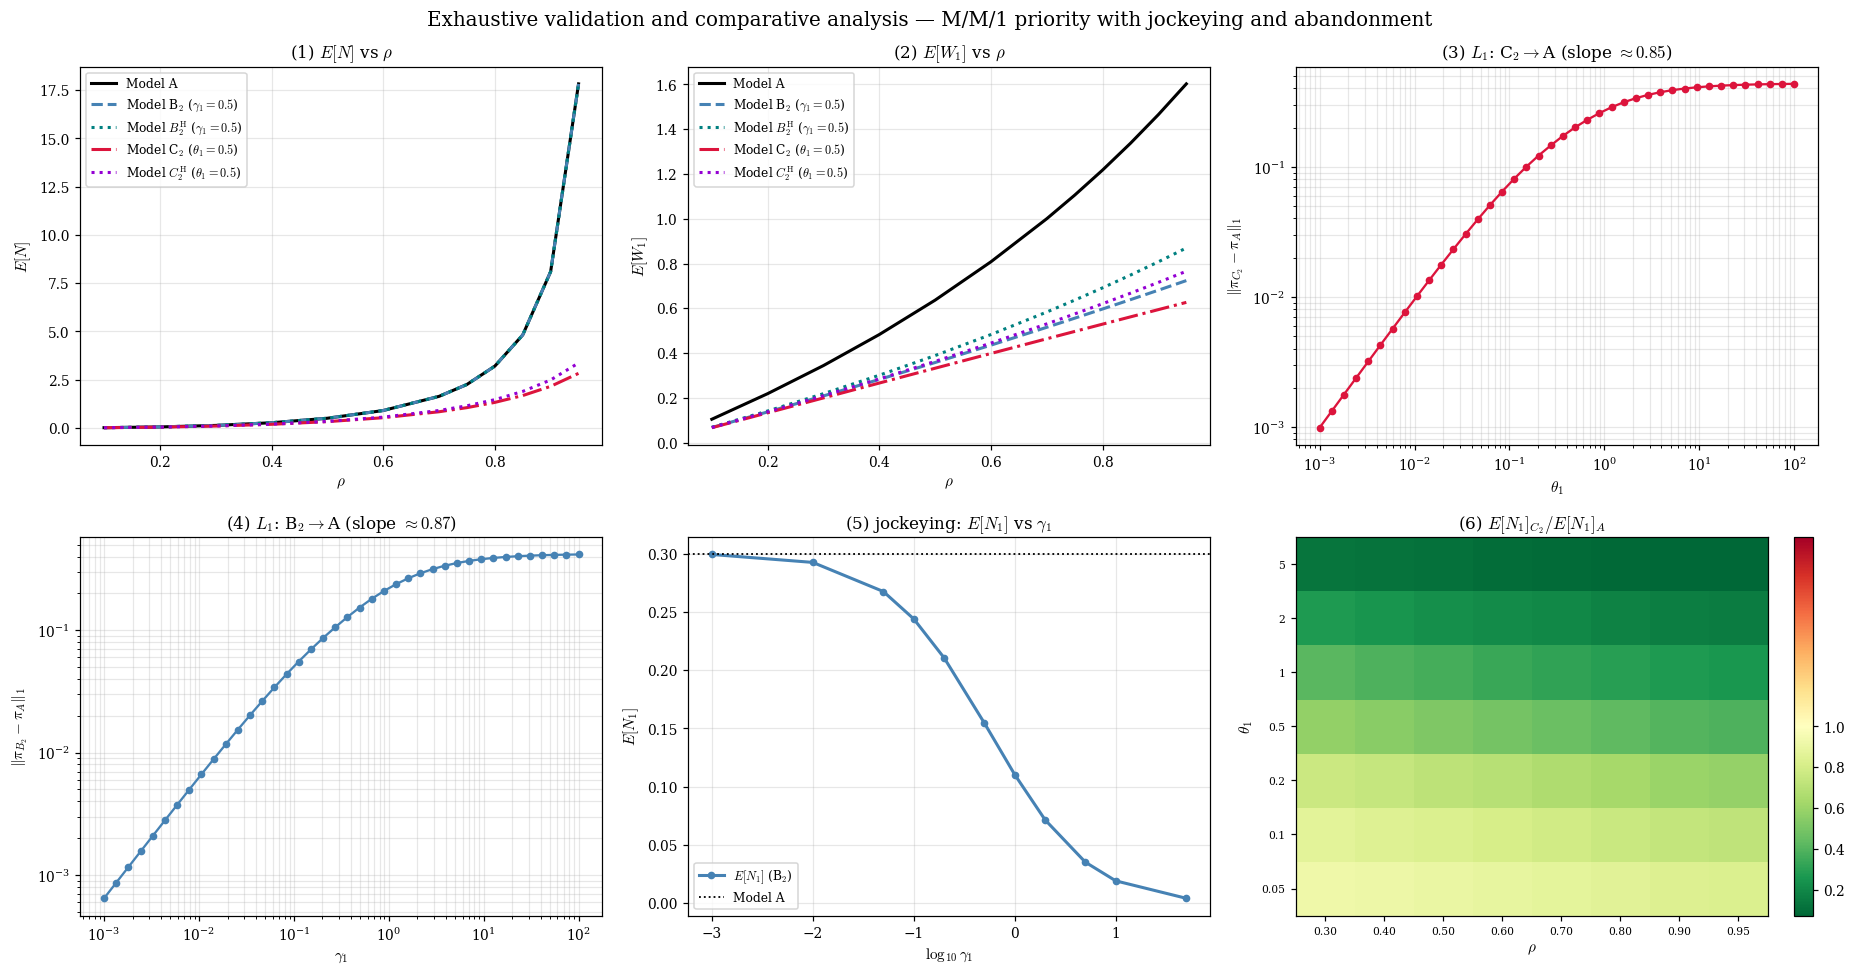

In [32]:

fig, ax = plt.subplots(2, 3, figsize=(17, 9))

# (1) E[N] vs rho
for m,(c,ls,lab) in STYLE.items():
    ax[0,0].plot(rho_arr, sweep[m]["En"], ls, color=c, lw=2, label=lab)
ax[0,0].set_xlabel(r"$\rho$"); ax[0,0].set_ylabel(r"$E[N]$")
ax[0,0].set_title(r"(1) $E[N]$ vs $\rho$"); ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=0.3)

# (2) E[W1] vs rho
for m,(c,ls,lab) in STYLE.items():
    ax[0,1].plot(rho_arr, sweep[m]["Ew1"], ls, color=c, lw=2, label=lab)
ax[0,1].set_xlabel(r"$\rho$"); ax[0,1].set_ylabel(r"$E[W_1]$")
ax[0,1].set_title(r"(2) $E[W_1]$ vs $\rho$"); ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=0.3)

# (3) L1 C2->A
mC = L1_C2 > 0
ax[0,2].loglog(theta1_conv[mC], L1_C2[mC], "o-", color=C_C2, ms=4, lw=1.5)
ax[0,2].set_xlabel(r"$\theta_1$"); ax[0,2].set_ylabel(r"$\|\pi_{C_2}-\pi_A\|_1$")
ax[0,2].set_title(rf"(3) $L_1$: C$_2\to$A (slope $\approx{slope_L1_C2:.2f}$)")
ax[0,2].grid(alpha=0.3, which="both")

# (4) L1 B2->A
mB = L1_B2 > 0
ax[1,0].loglog(gamma1_conv[mB], L1_B2[mB], "o-", color=C_B2, ms=4, lw=1.5)
ax[1,0].set_xlabel(r"$\gamma_1$"); ax[1,0].set_ylabel(r"$\|\pi_{B_2}-\pi_A\|_1$")
ax[1,0].set_title(rf"(4) $L_1$: B$_2\to$A (slope $\approx{slope_L1_B2:.2f}$)")
ax[1,0].grid(alpha=0.3, which="both")

# (5) E[N1] vs gamma1
ax[1,1].plot(lg, b2["En1"], "o-", color=C_B2, lw=2, ms=4, label=r"$E[N_1]$ (B$_2$)")
ax[1,1].axhline(dA["E_n1"], color="black", ls=":", lw=1.2, label="Model A")
ax[1,1].set_xlabel(r"$\log_{10}\gamma_1$"); ax[1,1].set_ylabel(r"$E[N_1]$")
ax[1,1].set_title(r"(5) jockeying: $E[N_1]$ vs $\gamma_1$"); ax[1,1].legend(fontsize=8)
ax[1,1].grid(alpha=0.3)

# (6) heatmap E[N1]_C2 / E[N1]_A
norm = TwoSlopeNorm(vmin=np.nanmin(ratio_grid), vcenter=1.0,
                    vmax=max(np.nanmax(ratio_grid), 1.0+1e-6))
im = ax[1,2].imshow(ratio_grid, origin="lower", aspect="auto", cmap="RdYlGn_r", norm=norm)
ax[1,2].set_xticks(range(len(RHO_HM))); ax[1,2].set_xticklabels([f"{r:.2f}" for r in RHO_HM], fontsize=7)
ax[1,2].set_yticks(range(len(TH_HM)));  ax[1,2].set_yticklabels([f"{t:g}" for t in TH_HM], fontsize=7)
ax[1,2].set_xlabel(r"$\rho$"); ax[1,2].set_ylabel(r"$\theta_1$")
ax[1,2].set_title(r"(6) $E[N_1]_{C_2}/E[N_1]_A$")
plt.colorbar(im, ax=ax[1,2], fraction=0.046)

fig.suptitle(r"Exhaustive validation and comparative analysis — "
             r"M/M/1 priority with jockeying and abandonment", fontsize=13)
fig.tight_layout()
savefig("fig_summary_dashboard")
plt.show()


---
**Done.** All figures saved to `figures/results/` (both `.pdf` and `.png`); LaTeX tables
written as `.tex` for `\input{}`. Theorem-by-theorem validation lives in
`nb_validation.ipynb`; this notebook is its comparative / convergence companion.